In [7]:
import pandas as pd
import os
import polars as pl
import joblib
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
import math
import matplotlib.gridspec as gridspec
import mplhep as hep
from scipy import stats
from scipy.stats import chi2
import pyBumpHunter as BH
import seaborn as sns

hep.style.use(hep.style.ROOT)

helpers_path = os.path.join('/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

## SETTINGS and LOADING EVENTS

In [8]:
selection = "ATLAS"
LUMI = 25.3845 # fb^-1
N_GEN_SIG = 100_000

SIGNAL_DIR = "/home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2"
SCALER_PATH = f"Final_Dataset_{selection}/minmax_scaler.joblib"
MODELS_DIR = f"Eval_CWoLa_SR_{selection}_ver2/"
model_path = f"Models_Extrapolation_{selection}_ver2"

METADATA_LIST = [
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0, "TheoryUnc": 0.52},
    {"Mass": 2000, "Rinv": 2, "XS": 146.3, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3, "TheoryUnc": 0.53},
    {"Mass": 3000, "Rinv": 2, "XS": 14.24, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26, "TheoryUnc": 0.48},
]
DF_META = pd.DataFrame(METADATA_LIST)

DEVICE = "cpu"
N_ENSEMBLE = 10
context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

scaler = joblib.load(SCALER_PATH)
device = torch.device("cpu")

SIGNAL_MODES = ["1000_2", "1000_4", "1000_6", "1000_8", "2000_2", "2000_4", "2000_6", "2000_8", "3000_2", "3000_4", "3000_6", "3000_8"]

In [9]:
def load_signal(mode_str, detector_mode,  base_path=SIGNAL_DIR):

    file_path = os.path.join(base_path, "SR", f"bsm_{mode_str}_{detector_mode}.parquet")
    if not os.path.exists(file_path):
        print(f"Error: Signal file {file_path} not found.")
        return None

    sig_pre_cols = [
        "tau21_j1", "tau32_j1", "tau21_j2", "tau32_j2", 
        "ht", "met_recalc_pt", "mjj"
    ]
    df_sim = pd.read_parquet(file_path, columns=sig_pre_cols)
    row = DF_META[(DF_META['Mass'] == int(mode_str.split("_")[0])) & (DF_META['Rinv'] == int(mode_str.split("_")[1]))]
    xs_eff, theory_unc = row.iloc[0]['XS'], row.iloc[0]['TheoryUnc']
    norm_factor = (xs_eff * LUMI) / N_GEN_SIG

    df_sim['weight'] = norm_factor
    
    rename_mapping = {
        "m_jj": "mjj",
        "tau21_j1": "ljet1_tau21",
        "tau32_j1": "ljet1_tau32",
        "tau21_j2": "ljet2_tau21",
        "tau32_j2": "ljet2_tau32",
        "met": "met_recalc_pt",
        "weight": "final_weight"
    }
    df_sim = df_sim.rename(columns=rename_mapping)
    
    return df_sim


In [10]:
def apply_sr_cuts(df):
    return df[
        (df["ht"] > 600) & 
        (df["met_recalc_pt"] > 600) & 
        (df["met_recalc_pt"] < 2000) & 
        (df["mjj"] < 10000) & 
        (df["ht"] < 4000)
    ]

def transform(df, scale=True):
    # 1. Create a copy immediately so the original remains untouched
    df_transformed = df.copy()
    
    # Order of the variables 
    features_to_scale = [
        'met_recalc_pt', 'ht', 
        'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]

    # 2. Apply transformations to the COPY
    if scale:
        df_transformed.loc[:, features_to_scale] = scaler.transform(df_transformed[features_to_scale].values).astype('float32')
    else:
        df_transformed.loc[:, features_to_scale] = scaler.inverse_transform(df_transformed[features_to_scale].values).astype('float32')
        
    # 3. Return the modified copy
    return df_transformed

def score_BSM(df, bkg_type, k = 5):
    features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

    sig_events_to_score = df[features_vars].values

    all_scores = []
    for i in range(k):
        model_name = f"model_Data_vs_{bkg_type}_ATLAS_fold{i + 1}.pt"
        NN = torch.load(f"{MODELS_DIR}/kfold/{model_name}", map_location=DEVICE, weights_only=False)
        NN.model.eval()

        scores_sig = NN.evaluation(sig_events_to_score).flatten()
        all_scores.append(scores_sig)

    df[f"bsm_score_{bkg_type}"] = np.median(all_scores, axis = 0)
    return df


def process_bsm_signal(sig_id, mode):
    """Loads and processes a single signal dataset."""
    df = load_signal(sig_id, mode)
    df = apply_sr_cuts(df)
    df = transform(df)
    df = score_BSM(df, "Nom")
    df = score_BSM(df, "Reweight_Median")
    df = score_BSM(df, "Generate_Combined")
    return df

In [11]:
# Load SR Data and Background (Nomnial, Reweight, and Generate)

df_data = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/DATA_SR_scored.parquet")
df_mc_rw = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_reweighted_scored.parquet")
nominal_w = df_mc_rw["final_weight"].values
rw_ensemble_weights = [df_mc_rw[f'reweight_weights_ens{i}'].values for i in range(N_ENSEMBLE)]
rw_median = np.median(rw_ensemble_weights, axis=0)
df_mc_rw["rw_mediam_weights"] = nominal_w * rw_median

gen_dfs = []
for i in range(N_ENSEMBLE):
    # Note: enumerate started at 0 in your saving script, so it's ens0 to ens4
    df = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_Generate_ens{i}_scored.parquet")
    
    # Scale the weights directly in the dataframe
    df['total_weight'] = df['total_weight'] / 10
    
    gen_dfs.append(df)
df_mc_gen = pd.concat(gen_dfs, ignore_index=True)

# Invert Scores since I mistakenly trained data to be 0 and background to be 1, but I want the opposite. So, I will invert the scores here.
df_data['score_vs_nominal'] = 1.0 - df_data['score_vs_nominal']
df_data['score_vs_reweighted'] = 1.0 - df_data['score_vs_reweighted']
df_data['score_vs_generate'] = 1.0 - df_data['score_vs_generate']

df_mc_rw['score_vs_data'] = 1.0 - df_mc_rw['score_vs_data']
df_mc_rw['score_vs_reweighted_data'] = 1.0 - df_mc_rw['score_vs_reweighted_data']

df_mc_gen['score_vs_data'] = 1.0 - df_mc_gen['score_vs_data']

In [12]:
detector_modes = ["default", "pu", "run2", "pu_run2"]
sig_dfs = {mode: {} for mode in detector_modes}

for mode in detector_modes:
    for sig_id in SIGNAL_MODES:
        # This runs your pipeline and stores it perfectly organized
        sig_dfs[mode][sig_id] = process_bsm_signal(sig_id, mode)

detector_type = "default" # default, pu, run2, pu_run2
df_sig_def = sig_dfs[detector_type]

# Invert Scores for Signal DataFrames
for sig_id in SIGNAL_MODES:
    df_sig_def[sig_id]['bsm_score_Nom'] = 1.0 - df_sig_def[sig_id]['bsm_score_Nom']
    df_sig_def[sig_id]['bsm_score_Reweight_Median'] = 1.0 - df_sig_def[sig_id]['bsm_score_Reweight_Median']
    df_sig_def[sig_id]['bsm_score_Generate_Combined'] = 1.0 - df_sig_def[sig_id]['bsm_score_Generate_Combined']

In [13]:
# Unscale back to physical values for analysis
df_data_unscaled = transform(df_data, scale=False)
df_mc_rw_unscaled = transform(df_mc_rw, scale=False)
df_mc_gen_unscaled = transform(df_mc_gen, scale=False)

df_sig_def_unscaled = {}

for sig_id in SIGNAL_MODES:
    df_sig_def_unscaled[sig_id] = transform(df_sig_def[sig_id], scale=False)

## Phase 1 (Background Only)

In [14]:
def apply_hybrid_cut(df_data, df_bkg, bkg_type, target_eff=0.01):
    """
    Finds the NN score threshold for the top X% of background and cuts both datasets.
    Uses predefined column configurations based on bkg_type ('NOM', 'RW', or 'GEN').
    """
    
    # 1. Map column names based on background type
    if bkg_type == "NOM":
        data_score_col = "score_vs_nominal"
        bkg_score_col = "score_vs_data"
        weight_col = "final_weight"
    elif bkg_type == "RW":
        data_score_col = "score_vs_reweighted"
        bkg_score_col = "score_vs_reweighted_data"
        weight_col = "rw_mediam_weights"
    elif bkg_type == "GEN":
        data_score_col = "score_vs_generate"
        bkg_score_col = "score_vs_data"
        weight_col = "total_weight"
    else:
        raise ValueError("bkg_type must be 'NOM', 'RW', or 'GEN'")

    # 2. Extract scores and weights
    bkg_scores = df_bkg[bkg_score_col].values
    bkg_weights = df_bkg[weight_col].values

    # 3. Sort to find the exact threshold based on weights
    sort_idx = np.argsort(bkg_scores)
    sorted_scores = bkg_scores[sort_idx]
    sorted_weights = np.abs(bkg_weights[sort_idx])
    
    cum_weights = np.cumsum(sorted_weights)
    if cum_weights[-1] == 0:
        raise ValueError("Total background weight is zero. Cannot compute threshold.")
        
    cum_weights_norm = cum_weights / cum_weights[-1]

    # 4. Find threshold for the target efficiency
    threshold_idx = np.searchsorted(cum_weights_norm, 1.0 - target_eff)
    
    # Protect against out-of-bounds index
    if threshold_idx >= len(sorted_scores):
        threshold_idx = len(sorted_scores) - 1
        
    threshold = sorted_scores[threshold_idx]
    
    print(f"--- {bkg_type} Cut ---")
    print(f"Applying cut at NN Score > {threshold:.4f} (Top {target_eff*100:.1f}% Background)")

    # 5. Filter and return new datasets
    data_sr = df_data[df_data[data_score_col] > threshold].copy()
    bkg_sr = df_bkg[df_bkg[bkg_score_col] > threshold].copy()
    
    return data_sr, bkg_sr, threshold

In [15]:
# Check inclusive pre-cut yields in the Signal Region
total_data_pre_cut = len(df_data_unscaled)
total_gen_pre_cut = df_mc_gen_unscaled['total_weight'].sum()
total_rw_pre_cut = df_mc_rw_unscaled['rw_mediam_weights'].sum()
total_nom_pre_cut = df_mc_rw_unscaled['final_weight'].sum()

print("="*20,"Pre-Cut Yields in Signal Region:", "="*20)

print(f"Pre-Cut Data Yield: {total_data_pre_cut}")
print(f"Pre-Cut GEN Yield:  {total_gen_pre_cut:.2f}")
print(f"Pre-Cut RW Yield:   {total_rw_pre_cut:.2f}")
print(f"Pre-Cut NOM Yield:  {total_nom_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/GEN):      {total_data_pre_cut / total_gen_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/RW):       {total_data_pre_cut / total_rw_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/NOM):      {total_data_pre_cut / total_nom_pre_cut:.2f}")


print("="*20,"Post-Cut Yields in Signal Region:", "="*20)
post_cut_data_nom, post_cut_nom, nom_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="NOM", target_eff=0.01)
post_cut_data_rw, post_cut_rw, rw_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="RW", target_eff=0.01)
post_cut_data_gen, post_cut_gen, gen_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_gen_unscaled, bkg_type="GEN", target_eff=0.01)

print()
print(f"Post-Cut Data Yield (NOM): {len(post_cut_data_nom)}")
print(f"Post-Cut Data Yield (RW): {len(post_cut_data_rw)}")
print(f"Post-Cut Data Yield (GEN): {len(post_cut_data_gen)}")
print(f"Post-Cut NOM Yield: {post_cut_nom['final_weight'].sum():.2f}")
print(f"Post-Cut RW Yield: {post_cut_rw['rw_mediam_weights'].sum():.2f}")
print(f"Post-Cut GEN Yield: {post_cut_gen['total_weight'].sum():.2f}")
print(f"Post-Cut Ratio (Data/NOM): {len(post_cut_data_nom) / post_cut_nom['final_weight'].sum():.2f}")
print(f"Post-Cut Ratio (Data/RW): {len(post_cut_data_rw) / post_cut_rw['rw_mediam_weights'].sum():.2f}")
print(f"Post-Cut Ratio (Data/GEN): {len(post_cut_data_gen) / post_cut_gen['total_weight'].sum():.2f}")

==================== Pre-Cut Yields in Signal Region: ====================
Pre-Cut Data Yield: 188757
Pre-Cut GEN Yield:  183843.73
Pre-Cut RW Yield:   183495.26
Pre-Cut NOM Yield:  185438.64
Pre-Cut Ratio (Data/GEN):      1.03
Pre-Cut Ratio (Data/RW):       1.03
Pre-Cut Ratio (Data/NOM):      1.02
==================== Post-Cut Yields in Signal Region: ====================
--- NOM Cut ---
Applying cut at NN Score > 0.5832 (Top 1.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5481 (Top 1.0% Background)
--- GEN Cut ---
Applying cut at NN Score > 0.5548 (Top 1.0% Background)

Post-Cut Data Yield (NOM): 2659
Post-Cut Data Yield (RW): 2250
Post-Cut Data Yield (GEN): 5014
Post-Cut NOM Yield: 1850.58
Post-Cut RW Yield: 1795.42
Post-Cut GEN Yield: 1834.40
Post-Cut Ratio (Data/NOM): 1.44
Post-Cut Ratio (Data/RW): 1.25
Post-Cut Ratio (Data/GEN): 2.73


### CHECK BACKGROUND MODELLING

In [16]:
def plot_corr_diff(corr_data, corr_bkg, corr_diff, bkg_type):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cmap = 'coolwarm'
    labels = [r'$m_{jj}$', r'Jet 1 $\tau_{21}$', r'Jet 1 $\tau_{32}$', r'Jet 2 $\tau_{21}$', r'Jet 2 $\tau_{32}$']

    # 1. Data Correlation
    sns.heatmap(corr_data, ax=axes[0], annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1, 
            xticklabels=labels, yticklabels=labels)
    axes[0].set_title("Data (Top 1% NN Score)", fontsize=14)

    sns.heatmap(corr_bkg, ax=axes[1], annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1, 
            xticklabels=labels, yticklabels=labels)
    axes[1].set_title(f"{bkg_type} Model (Top 1% NN Score)", fontsize=14)


    # A perfect generator would have all 0s here.
    sns.heatmap(corr_diff, ax=axes[2], annot=True, fmt=".2f", cmap="PiYG", vmin=-0.5, vmax=0.5, 
            xticklabels=labels, yticklabels=labels)
    axes[2].set_title(f"Difference (Data - {bkg_type})", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()


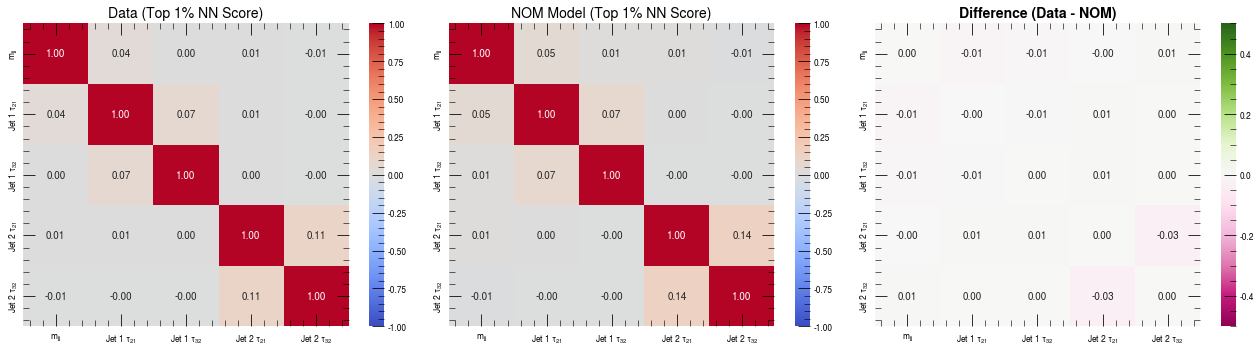

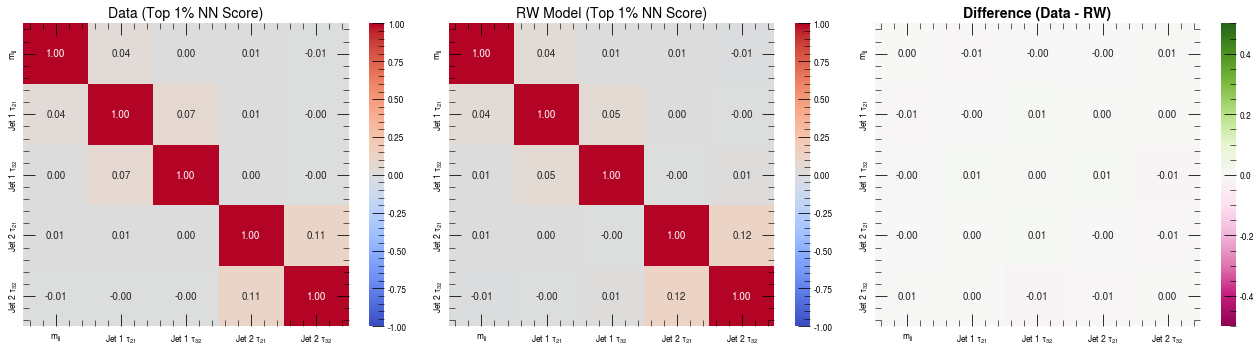

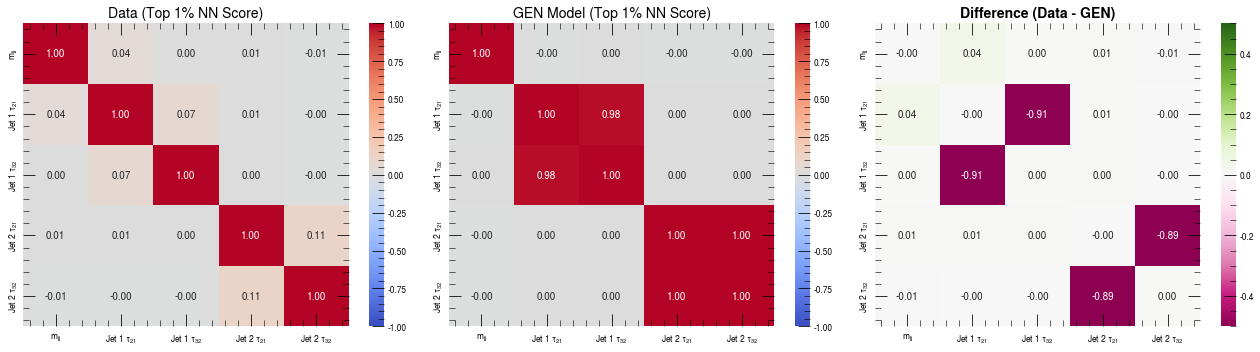

In [17]:
def get_weighted_correlation(df, features, weight_col):
    """Calculates the weighted Pearson correlation matrix."""
    # Extract arrays
    X = df[features].values
    w = df[weight_col].values
    w = np.abs(w)  # Ensure weights are non-negative
    # Calculate weighted covariance matrix (rowvar=False means columns are variables)
    cov_matrix = np.cov(X, rowvar=False, aweights=w)
    
    # Convert covariance to correlation matrix
    std_devs = np.sqrt(np.diag(cov_matrix))
    corr_matrix = cov_matrix / np.outer(std_devs, std_devs)
    
    return corr_matrix


features_list = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

# For Data, assume weight is 1.0 for all events if unweighted
if 'weight' not in df_data_unscaled.columns:
    df_data_unscaled['weight'] = 1.0

corr_data = get_weighted_correlation(df_data_unscaled, features_list, 'weight')
corr_nom = get_weighted_correlation(df_mc_rw_unscaled, features_list, 'final_weight')
corr_gen = get_weighted_correlation(df_mc_gen_unscaled, features_list, 'total_weight')
corr_rw = get_weighted_correlation(df_mc_rw_unscaled, features_list, 'rw_mediam_weights')

# The most important metric: where did the flow fail?
corr_diff_nom = corr_data - corr_nom
corr_diff_rw = corr_data - corr_rw
corr_diff_gen = corr_data - corr_gen


plot_corr_diff(corr_data, corr_nom, corr_diff_nom, bkg_type="NOM")
plot_corr_diff(corr_data, corr_rw, corr_diff_rw, bkg_type="RW")
plot_corr_diff(corr_data, corr_gen, corr_diff_gen, bkg_type="GEN")

GEN Background modelling has some issues in generating the $\tau_{21}$ and $\tau_{32}$ variables. Therefore only RW Background modelling will be used for the background only hypothesis

### NULL HYPOTHESIS TESTING

Statistical Variance ($\sigma_{\text{stat}, i}^2$)
$$\sigma_{\text{stat}, i}^2 = \sum_{k \in \text{bin } i} (w_{k})^2$$

ML Epistemic Systematic Variance ($\sigma_{\text{sys}, i}^2$) with a flat 5% ($0.05$) closure error derived from the control region.
$$B_{i, j} = \sum_{k \in \text{bin } i} \left( w_{\text{nominal}, k} \times \text{ens}_{j, k} \right)$$
$$\sigma_{\text{sys}, i} = B_i \times \sqrt{ \left( \frac{\sigma_{\text{ens}, i}}{B_i} \right)^2 + 0.05^2 }$$

In [18]:
import numpy as np
import pyBumpHunter as BH

# =====================================================================
# 1. SETUP & BINS
# =====================================================================
mjj_bins = np.concatenate([
    np.arange(400, 1000, 50), 
    np.arange(1000, 2000, 100), 
    np.arange(2000, 4200, 200)
])
n_bins = len(mjj_bins) - 1

# Calculate Data (N) and Reweighted Background (B) yields
N, _ = np.histogram(post_cut_data_rw['mjj'].values, bins=mjj_bins)
B, _ = np.histogram(post_cut_rw['mjj'].values, bins=mjj_bins, weights=post_cut_rw['rw_mediam_weights'].values)

# =====================================================================
# 2. STATISTICAL VARIANCE (UNCORRELATED)
# =====================================================================
# MC Statistical Error per bin (Sum of squared weights)
var_stat = np.histogram(
    post_cut_rw['mjj'].values, 
    bins=mjj_bins, 
    weights=post_cut_rw['rw_mediam_weights'].values**2
)[0]

# =====================================================================
# 3. MACHINE LEARNING (RW MODEL) SYSTEMATICS
# =====================================================================
# A. ML Epistemic Model Spread across 10 Ensemble Folds
ensemble_yields = np.zeros((10, n_bins))
for i in range(10):
    w_ens = post_cut_rw['final_weight'].values * post_cut_rw[f'reweight_weights_ens{i}'].values
    counts, _ = np.histogram(post_cut_rw['mjj'].values, bins=mjj_bins, weights=w_ens)
    ensemble_yields[i, :] = counts

ensemble_std = np.std(ensemble_yields, axis=0)
sys_ml_spread_frac = np.divide(ensemble_std, B, out=np.zeros_like(ensemble_std), where=B!=0)

# B. ML Non-Closure Error (Derived from CR validation AUC residual ~ 2.5% to 5%)
closure_err_frac = 0.05 

# Combine ML uncertainties (Spread + Non-Closure)
total_ml_err_frac = np.sqrt(sys_ml_spread_frac**2 + closure_err_frac**2)
std_ml_sys = total_ml_err_frac * B

# =====================================================================
# 4. EXPERIMENTAL & PHYSICS SYSTEMATICS (LUMI, JES, JER, THEORY)
# =====================================================================
# A. Luminosity Uncertainty
# Standard ATLAS Run-2 per-year/partial luminosity error is ~1.7% to 2.1% (To be conservative I use 5%)
lumi_err_frac = 0.05
std_lumi_sys = lumi_err_frac * B

# B. Jet Energy Scale (JES) & Jet Energy Resolution (JER)
# JES/JER causes shape distortions in the steeply falling mass spectrum.
# Modeled as a mass-dependent envelope: 3% at 400 GeV up to 15% at 4000 GeV
min_mass, max_mass = 400.0, 4000.0
min_jes_err, max_jes_err = 0.03, 0.15

std_jes_jer_sys = np.zeros(n_bins)
for i in range(n_bins):
    bin_center = (mjj_bins[i] + mjj_bins[i+1]) / 2.0
    jes_frac = min_jes_err + (max_jes_err - min_jes_err) * ((bin_center - min_mass) / (max_mass - min_mass))
    std_jes_jer_sys[i] = jes_frac * B[i]

# C. Theoretical PDF & Scale (\mu_R, \mu_F) Uncertainties
# Mass-dependent theoretical envelope: 5% at 400 GeV up to 20% at 4000 GeV
min_theory_err, max_theory_err = 0.05, 0.20

std_theory_sys = np.zeros(n_bins)
for i in range(n_bins):
    bin_center = (mjj_bins[i] + mjj_bins[i+1]) / 2.0
    theory_frac = min_theory_err + (max_theory_err - min_theory_err) * ((bin_center - min_mass) / (max_mass - min_mass))
    std_theory_sys[i] = theory_frac * B[i]

# =====================================================================
# 5. COMBINE ALL SYSTEMATIC STANDARD DEVIATIONS (PER BIN)
# =====================================================================
# Add independent systematic components in quadrature per bin
std_sys_total = np.sqrt(
    std_ml_sys**2 + 
    std_lumi_sys**2 + 
    std_jes_jer_sys**2 + 
    std_theory_sys**2
)

# Total Systematic Variance per bin
var_sys_total = std_sys_total**2

# =====================================================================
# 6. BUMPHUNTER SCAN
# =====================================================================
print(f"Surviving Data events: {N.sum():.0f}")
print(f"Surviving Bkg expected events: {B.sum():.2f}")

hunter = BH.BumpHunter1D(
    rang=[400, 4000],      
    width_min=2,           
    width_max=15,          
    width_step=1,          
    scan_step=1,           
    npe=10000,             
    nworker=4,             
    seed=42,               
    use_sideband=False     
)

print("Running pyBumpHunter scan...")
hunter.bump_scan(data=N, bkg=B, is_hist=True)

# =====================================================================
# 7. FINAL TEST STATISTIC (Z) WITH CORRELATED WINDOW SYSTEMATICS
# =====================================================================
print("\n--- Final Null Hypothesis Test ---")

if hasattr(hunter, 'min_loc_ar') and len(hunter.min_loc_ar) > 0:
    bump_start_idx = hunter.min_loc_ar[0]
    bump_end_idx = hunter.min_loc_ar[1]
    
    bump_start_mass = mjj_bins[bump_start_idx]
    bump_end_mass = mjj_bins[bump_end_idx + 1]
    
    print(f"Most significant mass window: {bump_start_mass:.1f} - {bump_end_mass:.1f} GeV")
    
    # 1. Window Yields
    obs_data = np.sum(N[bump_start_idx : bump_end_idx + 1])
    exp_bkg = np.sum(B[bump_start_idx : bump_end_idx + 1])
    
    # 2a. MC Stat Variance (Uncorrelated across bins: Sum of Variances)
    window_var_stat = np.sum(var_stat[bump_start_idx : bump_end_idx + 1])
    
    # 2b. Systematic Variance (Correlated across bins: Sum of Std Devs, then Squared)
    window_std_sys = np.sum(std_sys_total[bump_start_idx : bump_end_idx + 1])
    window_var_sys = window_std_sys**2
    
    # 3. Total Variance Equation: B + Var_stat + Var_sys_correlated
    total_variance = exp_bkg + window_var_stat + window_var_sys
    
    # 4. Significance Calculation (Z)
    if total_variance > 0:
        sys_sig = (obs_data - exp_bkg) / np.sqrt(total_variance)
    else:
        sys_sig = 0.0
        
    print(f"Window Data Yield:        {obs_data:.0f}")
    print(f"Window Background Yield:  {exp_bkg:.2f} ± {np.sqrt(window_var_stat + window_var_sys):.2f} (Stat+Sys)")
    print(f"  - MC Stat Uncertainty:   ± {np.sqrt(window_var_stat):.2f}")
    print(f"  - Systematics Uncertainty: ± {window_std_sys:.2f}")
    print(f"Test Statistic (Local Z): {sys_sig:.2f} sigma")
    
    if sys_sig < 2.0:
        print("\nCONCLUSION: Fail to reject H0. The anomaly is absorbed by Systematics (Lumi, JES, ML, Theory).")
    else:
        print("\nCONCLUSION: Reject H0. The anomaly SURVIVES all systematics! Potential Discovery.")
else:
    print("No significant bumps found. Fail to reject H0.")

Surviving Data events: 1412
Surviving Bkg expected events: 1141.85
Running pyBumpHunter scan...
Generating histograms
14 values of width will be tested
SCAN


Global p-value : 0.0000  (0 / 10000)
Significance > 3.71902 (lower limit)


--- Final Null Hypothesis Test ---
Most significant mass window: 400.0 - 1600.0 GeV
Window Data Yield:        1114
Window Background Yield:  888.24 ± 98.08 (Stat+Sys)
  - MC Stat Uncertainty:   ± 27.88
  - Systematics Uncertainty: ± 94.04
Test Statistic (Local Z): 2.20 sigma

CONCLUSION: Reject H0. The anomaly SURVIVES all systematics! Potential Discovery.


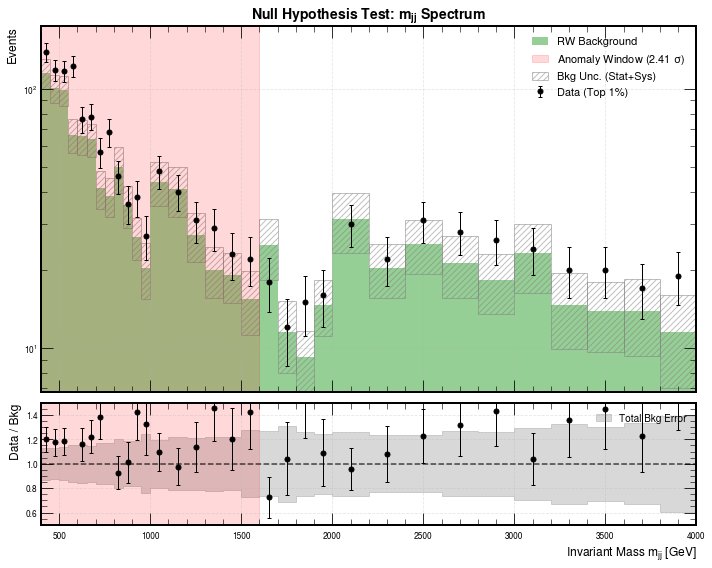

In [19]:
import matplotlib.pyplot as plt

# --- 1. PREPARE PLOTTING VARIABLES ---
bin_centers = (mjj_bins[:-1] + mjj_bins[1:]) / 2.0
bin_widths = np.diff(mjj_bins)

# Calculate total errors per bin
err_data = np.sqrt(N)
err_bkg_total = np.sqrt(var_stat + var_sys_total)

# Calculate ratios (safely avoiding division by zero)
ratio = np.divide(N, B, out=np.zeros_like(N, dtype=float), where=B!=0)
ratio_data_err = np.divide(err_data, B, out=np.zeros_like(err_data, dtype=float), where=B!=0)
ratio_bkg_err = np.divide(err_bkg_total, B, out=np.zeros_like(err_bkg_total, dtype=float), where=B!=0)

# --- 2. CREATE FIGURE & AXES ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(10, 8), 
    gridspec_kw={'height_ratios': [3, 1]}, 
    sharex=True
)

# --- 3. UPPER PANEL: MAIN SPECTRUM ---
# Background histogram
ax1.hist(mjj_bins[:-1], bins=mjj_bins, weights=B, color="#2ca02c", alpha=0.5, label="RW Background", histtype="stepfilled")

# Background total uncertainty band (Stat + Sys)
ax1.bar(
    bin_centers, 2 * err_bkg_total, bottom=B - err_bkg_total, 
    width=bin_widths, fill=False, hatch='////', edgecolor='gray', alpha=0.5, label="Bkg Unc. (Stat+Sys)"
)

# Data points
ax1.errorbar(
    bin_centers, N, yerr=err_data, 
    fmt='ko', label="Data (Top 1%)", capsize=2, elinewidth=1, markersize=5
)

# Highlight the BumpHunter anomaly window (400 to 1600 GeV)
ax1.axvspan(400, 1600, color='red', alpha=0.15, label="Anomaly Window (2.41 $\sigma$)")

# Formatting ax1
ax1.set_ylabel("Events", fontsize=12)
ax1.set_title(r"Null Hypothesis Test: $m_{jj}$ Spectrum", fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.set_xlim(mjj_bins[0], mjj_bins[-1])
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.3)

# --- 4. LOWER PANEL: RATIO PLOT ---
ax2.axhline(1.0, color='black', linestyle='--', alpha=0.7)

# Background fractional uncertainty band
ratio_bkg_band_upper = np.append(1 + ratio_bkg_err, (1 + ratio_bkg_err)[-1])
ratio_bkg_band_lower = np.append(1 - ratio_bkg_err, (1 - ratio_bkg_err)[-1])

ax2.fill_between(
    mjj_bins, ratio_bkg_band_lower, ratio_bkg_band_upper, 
    step='post', color='gray', alpha=0.3, label="Total Bkg Error"
)

# Highlight the same window in the ratio plot
ax2.axvspan(400, 1600, color='red', alpha=0.15)

# Data/Bkg points
ax2.errorbar(
    bin_centers, ratio, yerr=ratio_data_err, 
    fmt='ko', capsize=2, elinewidth=1, markersize=5
)

# Formatting ax2
ax2.set_xlabel(r"Invariant Mass $m_{jj}$ [GeV]", fontsize=12)
ax2.set_ylabel("Data / Bkg", fontsize=12)
ax2.set_ylim(0.5, 1.5) # Adjust this if the ratio spikes higher/lower
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Phase 2: BSM Signal

In [20]:
import pandas as pd

# List to store the results
h1_results = []

# Loop through all available BSM models
for sig_id in SIGNAL_MODES:
    df_sig = df_sig_def_unscaled[sig_id]
    
    # --- 1. APPLY THE SIGNAL REGION CUT ---
    # Apply the exact same 1% anomaly score threshold used for Data and Background
    sig_sr = df_sig[df_sig['bsm_score_Reweight_Median'] > rw_threshold]
    
    # --- 2. CALCULATE SIGNAL YIELDS & VARIANCE ---
    # Bin the surviving signal events into the same mjj_bins
    S_i, _ = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values)
    
    # Calculate the statistical variance of the signal (sum of squared weights)
    var_sig_stat_i = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values**2)[0]
    
    # If the signal is entirely killed by the anomaly cut, record 0 and skip
    if S_i.sum() <= 0:
        h1_results.append({
            "Model": sig_id, "Mass Window": "N/A", "Exp. B": 0, "Obs. Data": 0, 
            "Data Excess": 0, "Signal (S)": 0, "Exp. Z": 0.0, "Pull (H1)": np.nan
        })
        continue
        
    # --- 3. DYNAMICALLY DEFINE THE SIGNAL MASS WINDOW ---
    # A resonance is narrow. We find the bins where the signal yield is at least 
    # 5% of the peak signal bin to define the active signal window.
    active_bins = np.where(S_i > 0.05 * np.max(S_i))[0]
    start_idx = active_bins[0]
    end_idx = active_bins[-1]
    
    window_start_mass = mjj_bins[start_idx]
    window_end_mass = mjj_bins[end_idx + 1]
    
    # --- 4. EXTRACT YIELDS IN THE WINDOW ---
    S_win = np.sum(S_i[start_idx : end_idx + 1])
    B_win = np.sum(B[start_idx : end_idx + 1])
    N_win = np.sum(N[start_idx : end_idx + 1])
    
    # --- 5. EXTRACT & COMBINE VARIANCES IN THE WINDOW ---
    # Background variances (using the logic fixed in the previous steps)
    window_var_stat_bkg = np.sum(var_stat[start_idx : end_idx + 1])
    window_std_sys_bkg = np.sum(np.sqrt(var_sys_total[start_idx : end_idx + 1]))
    window_var_sys_bkg = window_std_sys_bkg**2  # Correlated squaring
    
    window_var_bkg = window_var_stat_bkg + window_var_sys_bkg
    
    # Signal statistical variance
    window_var_sig = np.sum(var_sig_stat_i[start_idx : end_idx + 1])
    
    # --- 6. CALCULATE HYPOTHESIS METRICS ---
    # Expected Significance (Sensitivity): S / sqrt(B + Var_B)
    Z_exp = S_win / np.sqrt(B_win + window_var_bkg) if (B_win + window_var_bkg) > 0 else 0
    
    # H1 Pull: (Data - (B + S)) / sqrt(B + S + Var_B + Var_S)
    # Note: B_win and S_win are included in the denominator as Poisson variance terms
    total_variance_H1 = B_win + S_win + window_var_bkg + window_var_sig
    pull_H1 = (N_win - (B_win + S_win)) / np.sqrt(total_variance_H1) if total_variance_H1 > 0 else 0
    
    # Data excess for contextual comparison
    excess_win = N_win - B_win
    
    # Append to results
    h1_results.append({
        "Model": sig_id,
        "Mass Window": f"{window_start_mass:.0f}-{window_end_mass:.0f}",
        "Exp. B": B_win,
        "Obs. Data": N_win,
        "Data Excess": excess_win,
        "Signal (S)": S_win,
        "Exp. Z": Z_exp,
        "Pull (H1)": pull_H1
    })

# --- 7. DISPLAY RESULTS ---
df_h1 = pd.DataFrame(h1_results)
print("\n--- Alternative Hypothesis (H1) Evaluation ---")
print(df_h1.to_string(index=False, float_format=lambda x: f"{x:.2f}" if isinstance(x, float) else x))


--- Alternative Hypothesis (H1) Evaluation ---
 Model Mass Window  Exp. B  Obs. Data  Data Excess  Signal (S)  Exp. Z  Pull (H1)
1000_2   1200-3600  310.01        367        56.99        9.70    0.17       0.82
1000_4    500-4000  926.52       1156       229.48       31.48    0.24       1.53
1000_6    600-3600  736.07        881       144.93       55.77    0.53       0.83
1000_8    450-3600 1001.53       1238       236.47       92.16    0.70       1.08
2000_2   1100-4000  376.33        443        66.67        2.04    0.03       0.93
2000_4    800-4000  552.35        638        85.65        5.07    0.06       0.89
2000_6    750-4000  590.88        706       115.12        8.31    0.09       1.13
2000_8    500-4000  926.52       1156       229.48        9.85    0.08       1.70
3000_2   1400-4000  288.19        343        54.81        0.06    0.00       0.95
3000_4    950-4000  440.50        518        77.50        0.23    0.00       1.00
3000_6    600-4000  761.42        917       155.58

In [21]:
# import pyhf
# import numpy as np
# import pandas as pd

# pyhf.set_backend("numpy")

# # --- 1. PREPARE THE SYSTEMATICS ARRAYS ---
# # We use the arrays we already built in the H0 step.
# # pyhf requires strict avoidance of 0-background bins for stability.
# valid_bins = B > 0

# B_valid = B[valid_bins]
# N_valid = N[valid_bins]
# err_stat_valid = np.sqrt(var_stat[valid_bins])  # Absolute stat error
# err_ml_valid = std_ml_sys[valid_bins]           # Absolute ML error

# # For correlated shape systematics (histosys), pyhf needs the absolute yields of the Up/Down shifts
# B_jes_up = B_valid + std_jes_jer_sys[valid_bins]
# B_jes_down = np.clip(B_valid - std_jes_jer_sys[valid_bins], a_min=1e-6, a_max=None)

# B_theory_up = B_valid + std_theory_sys[valid_bins]
# B_theory_down = np.clip(B_valid - std_theory_sys[valid_bins], a_min=1e-6, a_max=None)

# # List to store our rigorous pyhf results
# pyhf_results = []

# print("--- Running pyhf Profile Likelihood Fits for BSM Models ---")

# # --- 2. LOOP OVER SIGNALS & BUILD WORKSPACES ---
# for sig_id in SIGNAL_MODES:
#     df_sig = df_sig_def_unscaled[sig_id]
    
#     # Apply the exact 1% anomaly score threshold
#     sig_sr = df_sig[df_sig['bsm_score_Reweight_Median'] > rw_threshold]
    
#     # Calculate Signal Yield
#     S, _ = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values)
#     S_valid = S[valid_bins]
    
#     # Skip models entirely killed by the anomaly cut
#     if S_valid.sum() <= 1e-3:
#         pyhf_results.append({
#             "Model": sig_id, "Signal Yield": 0.0, 
#             "Best-fit Mu": np.nan, "Observed CLs": np.nan, "Expected CLs": np.nan
#         })
#         continue


#     # =====================================================================
#     # NEW: DYNAMIC MU SCAN CALCULATION
#     # =====================================================================
#     # Approximate the background variance using a simple Poisson sqrt(B)
#     approx_bkg_err = np.sqrt(B_valid.sum())
    
#     # Estimate the mu needed to hit a ~2 sigma excess
#     estimated_mu_limit = (2.0 * approx_bkg_err) / S_valid.sum()
    
#     # Set the max scan range to 3 times the estimate to give pyhf plenty of room.
#     # We clip it between 5.0 (for strong signals) and 200.0 (for impossibly weak signals).
#     mu_max = float(np.clip(estimated_mu_limit * 3.0, a_min=5.0, a_max=None))
    
#     # Create 51 points just within our custom, targeted range
#     scan_mu = np.linspace(0.0, mu_max, 51)
#     # =====================================================================


#     # --- 3. CONSTRUCT THE PYHF WORKSPACE ---
#     # This translates our arrays and uncertainties into a formal statistical model
#     workspace_dict = {
#         "channels": [
#             {
#                 "name": "signal_region",
#                 "samples": [
#                     {
#                         "name": "background",
#                         "data": B_valid.tolist(),
#                         "modifiers": [
#                             # 1. MC Statistical Error
#                             {"name": "staterror", "type": "staterror", "data": err_stat_valid.tolist()},
#                             # 2. Luminosity (1.7% normalization uncertainty)
#                             {"name": "lumi", "type": "normsys", "data": {"hi": 1.017, "lo": 0.983}},
#                             # 3. JES/JER (Correlated Shape uncertainty)
#                             {"name": "jes_jer", "type": "histosys", "data": {"hi_data": B_jes_up.tolist(), "lo_data": B_jes_down.tolist()}},
#                             # 4. Theory PDF/Scale (Correlated Shape uncertainty)
#                             {"name": "theory", "type": "histosys", "data": {"hi_data": B_theory_up.tolist(), "lo_data": B_theory_down.tolist()}},
#                             # 5. ML Epistemic Spread + Non-Closure (Uncorrelated bin-by-bin shape uncertainty)
#                             {"name": "ml_systematics", "type": "shapesys", "data": err_ml_valid.tolist()}
#                         ]
#                     },
#                     {
#                         "name": "signal",
#                         "data": S_valid.tolist(),
#                         "modifiers": [
#                             # The Parameter of Interest (POI)
#                             {"name": "mu", "type": "normfactor", "data": None}
#                         ]
#                     }
#                 ]
#             }
#         ],
#         "observations": [
#             {"name": "signal_region", "data": N_valid.tolist()}
#         ],
#         "measurements": [
#             {
#                 "name": "Measurement", 
#                 "config": {
#                     "poi": "mu", 
#                     "parameters": [
#                         {
#                             "name": "mu",
#                             "bounds": [[0.0, float(mu_max * 1.2)]]
#                         }
#                     ]
#                 }
#             }
#         ],
#         "version": "1.0.0"
#     }
    
#     # Build the model and data array (combining observations + auxiliary constraint data)
#     workspace = pyhf.Workspace(workspace_dict)
#     model = workspace.model()
#     data = workspace.data(model)
    
#     # # --- 4. PERFORM THE FITS ---
#     # try:
#     #     # A. Find the Best-Fit Signal Strength (mu_hat)
#     #     # This profiles the nuisance parameters to find what amount of signal the data actually prefers
#     #     best_fit_pars = pyhf.infer.mle.fit(data, model)
#     #     mu_hat = best_fit_pars[model.config.poi_index]
        
#     #     # B. Hypothesis Test for mu = 1.0 (Testing the nominal BSM cross-section)
#     #     # This calculates the CLs limit. If CLs < 0.05, the model is excluded at 95% CL.
#     #     obs_limit, exp_limits = pyhf.infer.hypotest(
#     #         1.0, data, model, test_stat="qtilde", return_expected_set=True
#     #     )
        
#     #     # The expected limit is typically returned as a band [-2sigma, -1sigma, median, +1sigma, +2sigma]
#     #     exp_limit_median = exp_limits[2]
        
#     #     pyhf_results.append({
#     #         "Model": sig_id,
#     #         "Signal Yield": S_valid.sum(),
#     #         "Best-fit Mu (mu_hat)": mu_hat,
#     #         "Observed CLs": obs_limit,
#     #         "Expected CLs": exp_limit_median
#     #     })
        
#     # except Exception as e:
#     #     print(f"Fit failed for {sig_id}: {e}")
#     #     pyhf_results.append({
#     #         "Model": sig_id, "Signal Yield": S_valid.sum(), 
#     #         "Best-fit Mu (mu_hat)": np.nan, "Observed CLs": np.nan, "Expected CLs": np.nan
#     #     })

#     # try:
#     # A. Find the Best-Fit Signal Strength (mu_hat)
#     best_fit_pars = pyhf.infer.mle.fit(data, model)
#     mu_hat = best_fit_pars[model.config.poi_index]
    
#     # B. Hypothesis Test / Upper Limit Calculation
#     # Increased the scan range to mu=20 to catch weaker signals
#     # scan_mu = np.linspace(0, 100, 101) 
    
#     obs_limit, exp_limits, details= pyhf.infer.intervals.upper_limits.upper_limit(
#         data, 
#         model, 
#         scan_mu, 
#         level=0.05, 
#         return_results=True
#     )
    
#     try:
#         # C. Safely extract ALL the expected limit bands
#         if isinstance(exp_limits, (list, tuple, np.ndarray)) and len(exp_limits) >= 5:
#             exp_m2  = float(np.asarray(exp_limits)[0]) # -2 sigma
#             exp_m1  = float(np.asarray(exp_limits)[1]) # -1 sigma
#             exp_med = float(np.asarray(exp_limits)[2]) # Median
#             exp_p1  = float(np.asarray(exp_limits)[3]) # +1 sigma
#             exp_p2  = float(np.asarray(exp_limits)[4]) # +2 sigma
#         else:
#             exp_m2 = exp_m1 = exp_med = exp_p1 = exp_p2 = np.nan
            
#         # D. Safely extract the observed limit
#         try:
#             obs_limit = float(np.asarray(obs_limit))
#         except (TypeError, ValueError):
#             obs_limit = np.nan
        
#         pyhf_results.append({
#             "Model": sig_id,
#             "Signal Yield": S_valid.sum(),
#             "Best-fit Mu": mu_hat,
#             "Obs_Limit": obs_limit,
#             "Exp_m2": exp_m2,
#             "Exp_m1": exp_m1,
#             "Exp_med": exp_med,
#             "Exp_p1": exp_p1,
#             "Exp_p2": exp_p2
#         })
#     except Exception as e:
#         print(f"Fit failed for {sig_id}: {e}")
#         pyhf_results.append({
#             "Model": sig_id, "Signal Yield": S_valid.sum(), 
#             "Best-fit Mu": np.nan, "Obs_Limit": np.nan, "Exp_m2": np.nan, "Exp_m1": np.nan, "Exp_med": np.nan, "Exp_p1": np.nan, "Exp_p2": np.nan
#         })

# # --- 5. DISPLAY RESULTS ---
# df_pyhf = pd.DataFrame(pyhf_results)
# print("\n--- pyhf Profile Likelihood Results ---")
# print(df_pyhf.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else x))

In [22]:
# df_pyhf.to_csv("pyhf_results.csv", index=False)

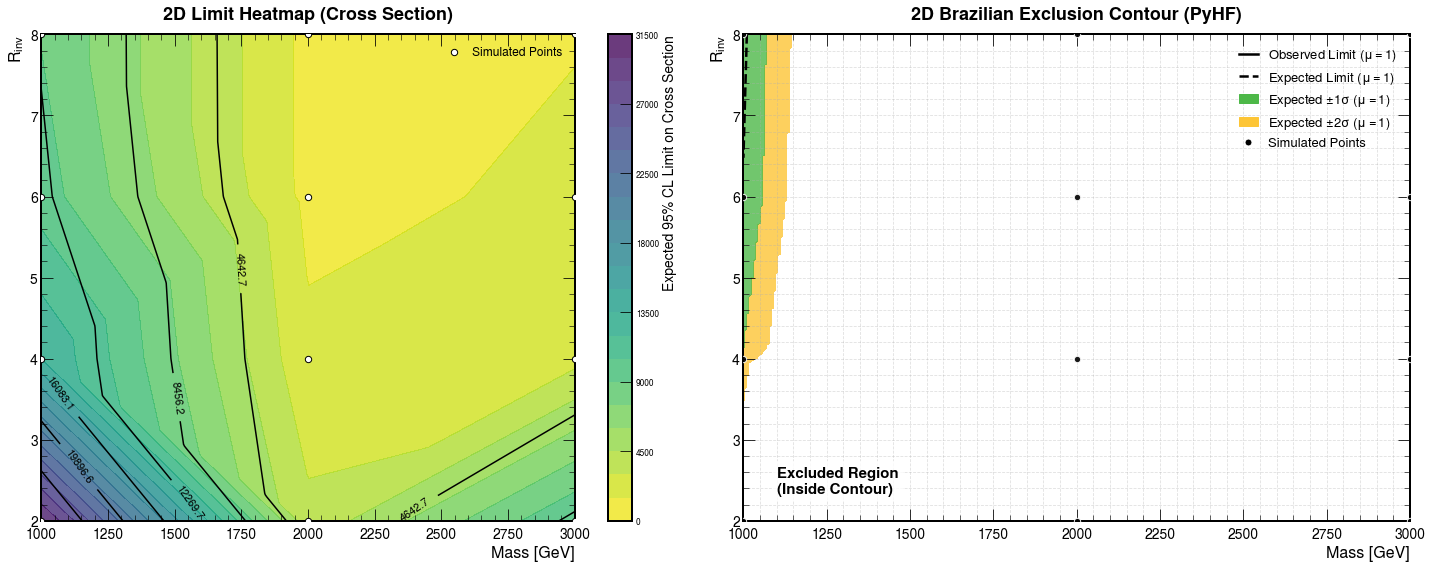

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

def plot_2d_bsm_limits_corrected(df, 
                                 mass_col='Mass', 
                                 rinv_col='Rinv', 
                                 xs_col='XS',
                                 obs_col='Obs_Limit', 
                                 med_col='Exp_med',
                                 m1_col='Exp_m1', 
                                 p1_col='Exp_p1', 
                                 m2_col='Exp_m2', 
                                 p2_col='Exp_p2',
                                 exclusion_threshold=1.0,
                                 title_suffix="(PyHF)"):
    """
    Plots a 2D Heatmap (in Cross Section) and a 2D Brazilian Contour (in mu) side-by-side.
    """
    # Drop rows where limits or theoretical XS could not be found
    df_plot = df.dropna(subset=[med_col, obs_col, xs_col]).copy()
    
    x = df_plot[mass_col].values
    y = df_plot[rinv_col].values
    
    # Create the 2D Interpolation Grid (300x300 density)
    xi = np.linspace(x.min(), x.max(), 300)
    yi = np.linspace(y.min(), y.max(), 300)
    X, Y = np.meshgrid(xi, yi)
    
    # =====================================================================
    # INTERPOLATE FOR HEATMAP (CROSS SECTION)
    # =====================================================================
    # Multiply the mu limits by the theoretical cross section
    z_med_xs = df_plot[med_col].values * df_plot[xs_col].values
    z_obs_xs = df_plot[obs_col].values * df_plot[xs_col].values
    
    Z_med_XS = griddata((x, y), z_med_xs, (X, Y), method='linear')
    Z_obs_XS = griddata((x, y), z_obs_xs, (X, Y), method='linear')
    
    # =====================================================================
    # INTERPOLATE FOR BRAZILIAN CONTOUR (SIGNAL STRENGTH MU)
    # =====================================================================
    Z_obs = griddata((x, y), df_plot[obs_col].values, (X, Y), method='linear')
    Z_med = griddata((x, y), df_plot[med_col].values, (X, Y), method='linear')
    Z_m1  = griddata((x, y), df_plot[m1_col].values, (X, Y), method='linear')
    Z_p1  = griddata((x, y), df_plot[p1_col].values, (X, Y), method='linear')
    Z_m2  = griddata((x, y), df_plot[m2_col].values, (X, Y), method='linear')
    Z_p2  = griddata((x, y), df_plot[p2_col].values, (X, Y), method='linear')
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # =====================================================================
    # PLOT 1: 2D LIMIT HEATMAP (CROSS SECTION)
    # =====================================================================
    ax1 = axes[0]
    
    # Draw expected limit heatmap in XS
    cf1 = ax1.contourf(X, Y, Z_med_XS, cmap='viridis_r', levels=20, alpha=0.8)
    cbar = fig.colorbar(cf1, ax=ax1)
    cbar.set_label('Expected 95% CL Limit on Cross Section', fontsize=14)
    
    # Draw observed limit contours in XS
    try:
        if not np.isnan(Z_obs_XS).all():
            obs_levels = np.linspace(np.nanmin(Z_obs_XS), np.nanmax(Z_obs_XS), 8)
            cs1 = ax1.contour(X, Y, Z_obs_XS, colors='black', linestyles='solid', linewidths=1.5, levels=obs_levels)
            ax1.clabel(cs1, inline=True, fontsize=11, fmt='%1.1f')
    except Exception:
        pass
        
    ax1.scatter(x, y, color='white', edgecolor='black', s=40, zorder=5, label='Simulated Points')
    ax1.set_xlabel('Mass [GeV]', fontsize=16)
    ax1.set_ylabel(r'$R_{inv}$', fontsize=16)
    ax1.set_title(f'2D Limit Heatmap (Cross Section)', fontsize=18, fontweight='bold', pad=15)
    ax1.legend(loc='upper right', fontsize=12)
    ax1.tick_params(axis='both', labelsize=14)
    
    # =====================================================================
    # PLOT 2: 2D BRAZILIAN CONTOUR (SIGNAL STRENGTH MU)
    # =====================================================================
    ax2 = axes[1]
    
    band_grid = np.zeros_like(X)
    band_grid[(Z_m2 <= exclusion_threshold) & (Z_m1 > exclusion_threshold)] = 1
    band_grid[(Z_p1 <= exclusion_threshold) & (Z_p2 > exclusion_threshold)] = 1
    band_grid[(Z_m1 <= exclusion_threshold) & (Z_p1 > exclusion_threshold)] = 2
    
    ax2.contourf(X, Y, band_grid, levels=[0.5, 1.5, 2.5], colors=['#FDC536', '#4DB848'], alpha=0.8)
    
    try:
        ax2.contour(X, Y, Z_med, levels=[exclusion_threshold], colors='black', linestyles='dashed', linewidths=2.5)
    except ValueError:
        pass 
        
    try:
        ax2.contour(X, Y, Z_obs, levels=[exclusion_threshold], colors='black', linestyles='solid', linewidths=2.5)
    except ValueError:
        pass 
        
    ax2.scatter(x, y, color='black', s=40, edgecolor='white', alpha=0.9, zorder=5, label='Simulated Points')
    
    yellow_patch = mpatches.Patch(color='#FDC536', label=r'Expected $\pm 2\sigma$ ($\mu=1$)')
    green_patch  = mpatches.Patch(color='#4DB848', label=r'Expected $\pm 1\sigma$ ($\mu=1$)')
    exp_line     = mlines.Line2D([], [], color='black', linestyle='dashed', linewidth=2.5, label='Expected Limit ($\mu=1$)')
    obs_line     = mlines.Line2D([], [], color='black', linestyle='solid', linewidth=2.5, label='Observed Limit ($\mu=1$)')
    points       = mlines.Line2D([], [], color='black', marker='o', markeredgecolor='white', linestyle='None', markersize=7, label='Simulated Points')
    
    ax2.legend(handles=[obs_line, exp_line, green_patch, yellow_patch, points], loc='upper right', fontsize=13, framealpha=0.95)
    
    ax2.set_xlabel('Mass [GeV]', fontsize=16)
    ax2.set_ylabel(r'$R_{inv}$', fontsize=16)
    ax2.set_title(f'2D Brazilian Exclusion Contour {title_suffix}', fontsize=18, fontweight='bold', pad=15)
    
    ax2.text(0.05, 0.05, "Excluded Region\n(Inside Contour)", transform=ax2.transAxes, 
            fontsize=15, fontweight='bold', color='black', verticalalignment='bottom', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5))
            
    ax2.tick_params(axis='both', labelsize=14)
    ax2.grid(True, which='both', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

# Example Usage:
# Assuming df_pyhf and DF_META are loaded
df_pyhf = pd.read_csv('pyhf_results.csv')
df_pyhf[['Mass', 'Rinv']] = df_pyhf['Model'].str.split('_', expand=True).astype(float)
df_merged = pd.merge(df_pyhf, DF_META, on=['Mass', 'Rinv'])
plot_2d_bsm_limits_corrected(df_merged)

In [24]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)

In [ ]:
pyhf_results = []

# --- 2. LOOP OVER SIGNALS & BUILD WORKSPACES ---
for sig_id in SIGNAL_MODES:
    df_sig = df_sig_def_unscaled[sig_id]
    
    # Apply the exact 1% anomaly score threshold
    sig_sr = df_sig[df_sig['bsm_score_Reweight_Median'] > rw_threshold]
    
    # Calculate Signal Yield
    S, _ = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values)
    S_valid = S[valid_bins]
    
    # --- SAFETY MECHANISM 1: BYPASS DEAD SIGNALS ---
    # If the signal is too small, pyhf will crash with 0/0. Hardcode to 1.0.
    if S_valid.sum() <= 1.0:
        pyhf_results.append({
            "Model": sig_id, 
            "Signal Yield": S_valid.sum(),
            "Best-fit Mu": 0.0, 
            "Observed CLs": 1.0,
            "Exp CLs -2s": 1.0,
            "Exp CLs -1s": 1.0,
            "Exp CLs Med": 1.0,
            "Exp CLs +1s": 1.0,
            "Exp CLs +2s": 1.0
        })
        continue

    # --- 3. CONSTRUCT THE PYHF WORKSPACE ---
    workspace_dict = {
        "channels": [
            {
                "name": "signal_region",
                "samples": [
                    {
                        "name": "background",
                        "data": B_valid.tolist(),
                        "modifiers": [
                            {"name": "staterror", "type": "staterror", "data": err_stat_valid.tolist()},
                            {"name": "lumi", "type": "normsys", "data": {"hi": 1.017, "lo": 0.983}},
                            {"name": "jes_jer", "type": "histosys", "data": {"hi_data": B_jes_up.tolist(), "lo_data": B_jes_down.tolist()}},
                            {"name": "theory", "type": "histosys", "data": {"hi_data": B_theory_up.tolist(), "lo_data": B_theory_down.tolist()}},
                            {"name": "ml_systematics", "type": "shapesys", "data": err_ml_valid.tolist()}
                        ]
                    },
                    {
                        "name": "signal",
                        "data": S_valid.tolist(),
                        "modifiers": [
                            {"name": "mu", "type": "normfactor", "data": None}
                        ]
                    }
                ]
            }
        ],
        "observations": [{"name": "signal_region", "data": N_valid.tolist()}],
        "measurements": [{"name": "Measurement", "config": {"poi": "mu", "parameters": []}}],
        "version": "1.0.0"
    }
    
    workspace = pyhf.Workspace(workspace_dict)
    model = workspace.model()
    data = workspace.data(model)
    
    # --- 4. PERFORM THE FITS ---
    try:
        # A. Find the Best-Fit Signal Strength (mu_hat)
        best_fit_pars = pyhf.infer.mle.fit(data, model)
        mu_hat = best_fit_pars[model.config.poi_index]
        
        # B. Hypothesis Test for mu = 1.0
        obs_limit, exp_limits = pyhf.infer.hypotest(
            1.0, data, model, test_stat="qtilde", return_expected_set=True
        )
        
        # --- SAFETY MECHANISM 2: CATCH NANS ---
        # Convert to standard floats, replacing NaNs with 1.0
        obs_limit = 1.0 if np.isnan(obs_limit) else float(obs_limit)
        exp_limits = [1.0 if np.isnan(x) else float(x) for x in exp_limits]
        
        pyhf_results.append({
            "Model": sig_id,
            "Signal Yield": S_valid.sum(),
            "Best-fit Mu": float(mu_hat) if not np.isnan(mu_hat) else 0.0,
            "Observed CLs": obs_limit,
            "Exp CLs -2s": exp_limits[0],
            "Exp CLs -1s": exp_limits[1],
            "Exp CLs Med": exp_limits[2],
            "Exp CLs +1s": exp_limits[3],
            "Exp CLs +2s": exp_limits[4]
        })
        
    except Exception as e:
        print(f"Fit failed for {sig_id}: {e}")
        pyhf_results.append({
            "Model": sig_id, "Signal Yield": S_valid.sum(),
            "Best-fit Mu": 0.0, "Observed CLs": 1.0,
            "Exp CLs -2s": 1.0, "Exp CLs -1s": 1.0, "Exp CLs Med": 1.0, "Exp CLs +1s": 1.0, "Exp CLs +2s": 1.0
        })

# --- 5. DISPLAY RESULTS ---
df_pyhf = pd.DataFrame(pyhf_results)
print("\n--- pyhf Profile Likelihood Results ---")
print(df_pyhf.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else x))


--- pyhf Profile Likelihood Results ---
 Model  Signal Yield  Best-fit Mu  Observed CLs  Exp CLs -2s  Exp CLs -1s  Exp CLs Med  Exp CLs +1s  Exp CLs +2s
1000_2        9.6979       0.0000        0.4714       0.1900       0.3277       0.5314       0.7677       0.9366
1000_4       31.4819       0.2383        0.2305       0.0154       0.0531       0.1646       0.4140       0.7461
1000_6       55.7687       0.4175        0.1636       0.0019       0.0108       0.0540       0.2105       0.5416
1000_8       92.1589       0.4430        0.1419       0.0009       0.0059       0.0348       0.1585       0.4665
2000_2        2.0426       0.0000        0.8904       0.8195       0.8792       0.9342       0.9753       0.9950
2000_4        5.0680       0.0000        0.7986       0.6877       0.7840       0.8781       0.9525       0.9901
2000_6        8.3445       0.0000        0.7006       0.5278       0.6580       0.7973       0.9167       0.9817
2000_8        9.8479       0.0000        0.6845       0

In [ ]:
.

In [ ]:
def optimize_cut_threshold_ver2(df_sig_dict, df_bkg, bkg_type, sig_modes, thres_min):
    if bkg_type == "NOM":
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Nom"
        bkg_weight_name = "final_weight"
    elif bkg_type == "RW":
        bkg_col_score = "score_vs_reweighted_data"
        sig_col_score = "bsm_score_Reweight_Median"
        bkg_weight_name = "rw_mediam_weights"
    elif bkg_type == "GEN":
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Generate_Combined"
        bkg_weight_name = "total_weight"
    else:
        raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")

    thresholds = np.linspace(0, 1.0, 100)
    num_modes = len(sig_modes)
    
    # 1. Pre-calculate background yields
    b_yields = np.zeros(len(thresholds))
    for idx, thresh in enumerate(thresholds):
        b_mask = df_bkg[bkg_col_score] > thresh
        b_yields[idx] = df_bkg.loc[b_mask, bkg_weight_name].sum()

    # 2. Setup dynamic grid: Max 4 columns per row
    cols = min(4, num_modes)
    rows = math.ceil(num_modes / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows), squeeze=False)
    fig.suptitle(f"Cut Optimization vs {bkg_type} Background", fontsize=16, fontweight='bold', y=1.02)
    
    # Flatten axes array for easy 1D indexing in the loop
    axes_flat = axes.flatten()
    
    results = {}

    # 3. Loop through each signal mode
    for i, sig_mode in enumerate(sig_modes):
        # Extract the dataframe from the dictionary using the sig_mode key
        df_sig = df_sig_dict[sig_mode] 
        
        mass = sig_mode.split("_")[0]
        rinv = f"0.{sig_mode.split('_')[1]}"
        
        s_yields = np.zeros(len(thresholds))
        significances = np.zeros(len(thresholds))
        
        for idx, thresh in enumerate(thresholds):
            s_mask = df_sig[sig_col_score] > thresh
            S = df_sig.loc[s_mask, "final_weight"].sum()
            B = b_yields[idx]
            
            s_yields[idx] = S
            
            # --- INCORPORATED STATISTICAL FLOOR ---
            if B > 0 and S > 0:
                # Enforce a minimum signal and background yield to ensure stable limits
                # and prevent dividing by zero or suffering extreme Poisson fluctuations
                if S < 5.0 or B < 50.0:
                    significances[idx] = 0.0
                else:
                    significances[idx] = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
            else:
                significances[idx] = 0.0
            # ---------------------------------------

        max_idx = np.argmax(significances)
        max_Z = significances[max_idx]
        opt_thresh = thresholds[max_idx]
        opt_S = s_yields[max_idx]
        opt_B = b_yields[max_idx]
        
        results[sig_mode] = {
            "mass": mass, "rinv": rinv, "opt_thresh": opt_thresh, 
            "max_Z": max_Z, "opt_S": opt_S, "opt_B": opt_B
        }

        # --- Plotting ---
        ax1 = axes_flat[i]
        
        ax1.plot(thresholds, significances, color='purple', lw=2.5, label=r'Expected Sig (Max: %.2f $\sigma$)' % max_Z)
        ax1.axvline(opt_thresh, color='red', linestyle='--', label=f'Opt Cut: > {opt_thresh:.4f}')
        
        ax1.set_xlabel("Anomaly Score Threshold", fontsize=11)
        
        # Only label the left Y-axis on the first column of every row
        if i % cols == 0:
            ax1.set_ylabel("Significance (Asimov Z)", fontsize=12)
            
        ax1.set_title(f"({mass}, {rinv})", fontsize=14, fontweight='bold')
        ax1.legend(loc='upper left', frameon=True)
        ax1.grid(True, linestyle="--", alpha=0.4)
        
        ax2 = ax1.twinx()
        ax2.plot(thresholds, s_yields, color='blue', linestyle=':', alpha=0.7, label='Signal (S)')
        ax2.plot(thresholds, b_yields, color='orange', linestyle=':', alpha=0.7, label='Bkg (B)')
        
        ax2.set_yscale('log')
        
        # Only label the right Y-axis on the last column of every row, or the very last plot
        if (i % cols == cols - 1) or (i == num_modes - 1):
            ax2.set_ylabel("Expected Event Yield", fontsize=12)
            
        ax2.legend(loc='upper right', frameon=True)

    # 4. Hide any unused subplots (if num_modes is not a perfect multiple of 4)
    for j in range(num_modes, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.show()
    
    # 5. Print summary
    print("-" * 55)
    print(f"OPTIMAL CUT SUMMARY vs {bkg_type}")
    print("-" * 55)
    for mode, res in results.items():
        print(f"Signal ({res['mass']}, {res['rinv']}):")
        print(f"  Optimal Threshold : > {res['opt_thresh']:.4f}")
        print(f"  Max Significance  : {res['max_Z']:.2f} sigma")
        print(f"  Expected Signal   : {res['opt_S']:.2f}")
        print(f"  Expected Bkg      : {res['opt_B']:.2f}")
        print("-" * 30)
    
    return results

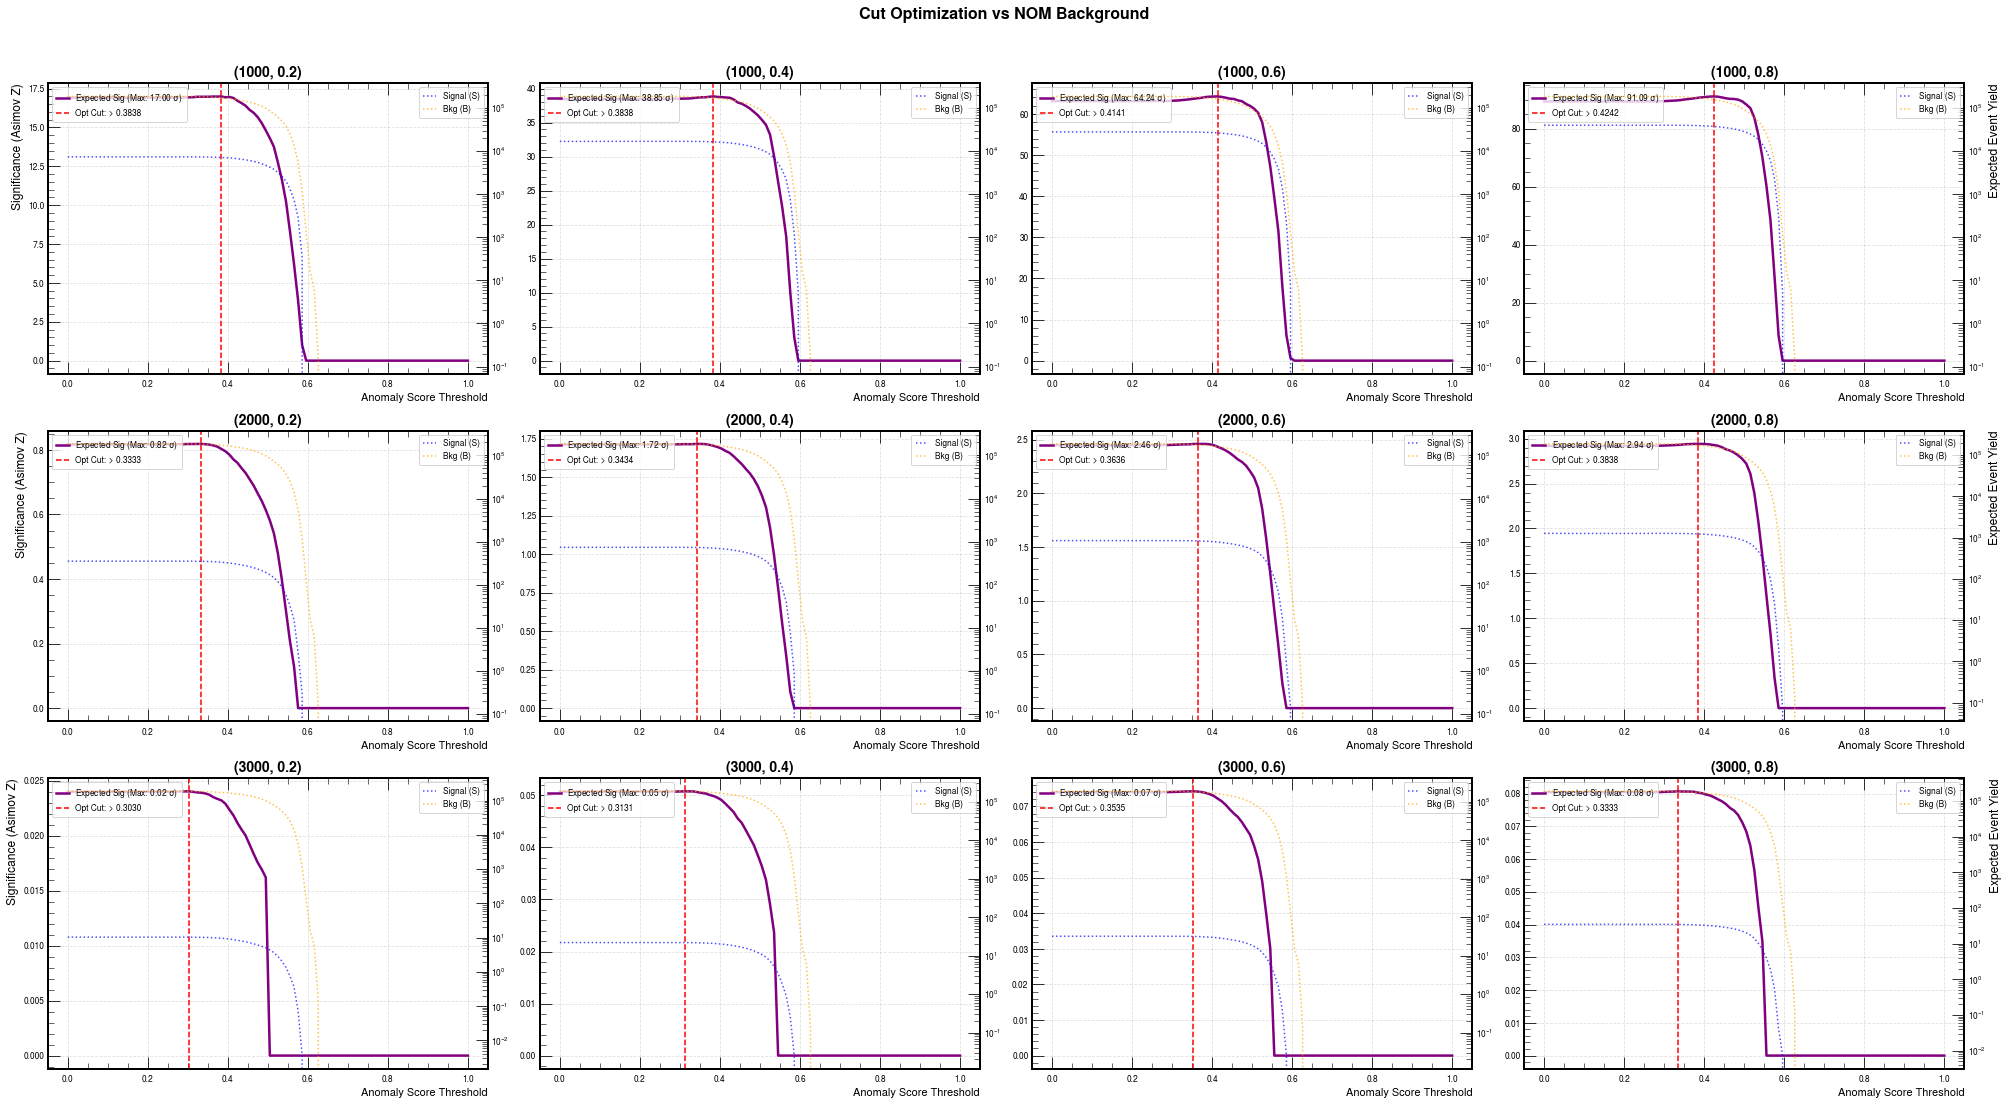

-------------------------------------------------------
OPTIMAL CUT SUMMARY vs NOM
-------------------------------------------------------
Signal (1000, 0.2):
  Optimal Threshold : > 0.3838
  Max Significance  : 17.00 sigma
  Expected Signal   : 7103.71
  Expected Bkg      : 172277.79
------------------------------
Signal (1000, 0.4):
  Optimal Threshold : > 0.3838
  Max Significance  : 38.85 sigma
  Expected Signal   : 16375.41
  Expected Bkg      : 172277.79
------------------------------
Signal (1000, 0.6):
  Optimal Threshold : > 0.4141
  Max Significance  : 64.24 sigma
  Expected Signal   : 26407.71
  Expected Bkg      : 160423.56
------------------------------
Signal (1000, 0.8):
  Optimal Threshold : > 0.4242
  Max Significance  : 91.09 sigma
  Expected Signal   : 37261.31
  Expected Bkg      : 155366.71
------------------------------
Signal (2000, 0.2):
  Optimal Threshold : > 0.3333
  Max Significance  : 0.82 sigma
  Expected Signal   : 349.87
  Expected Bkg      : 182610.96
-

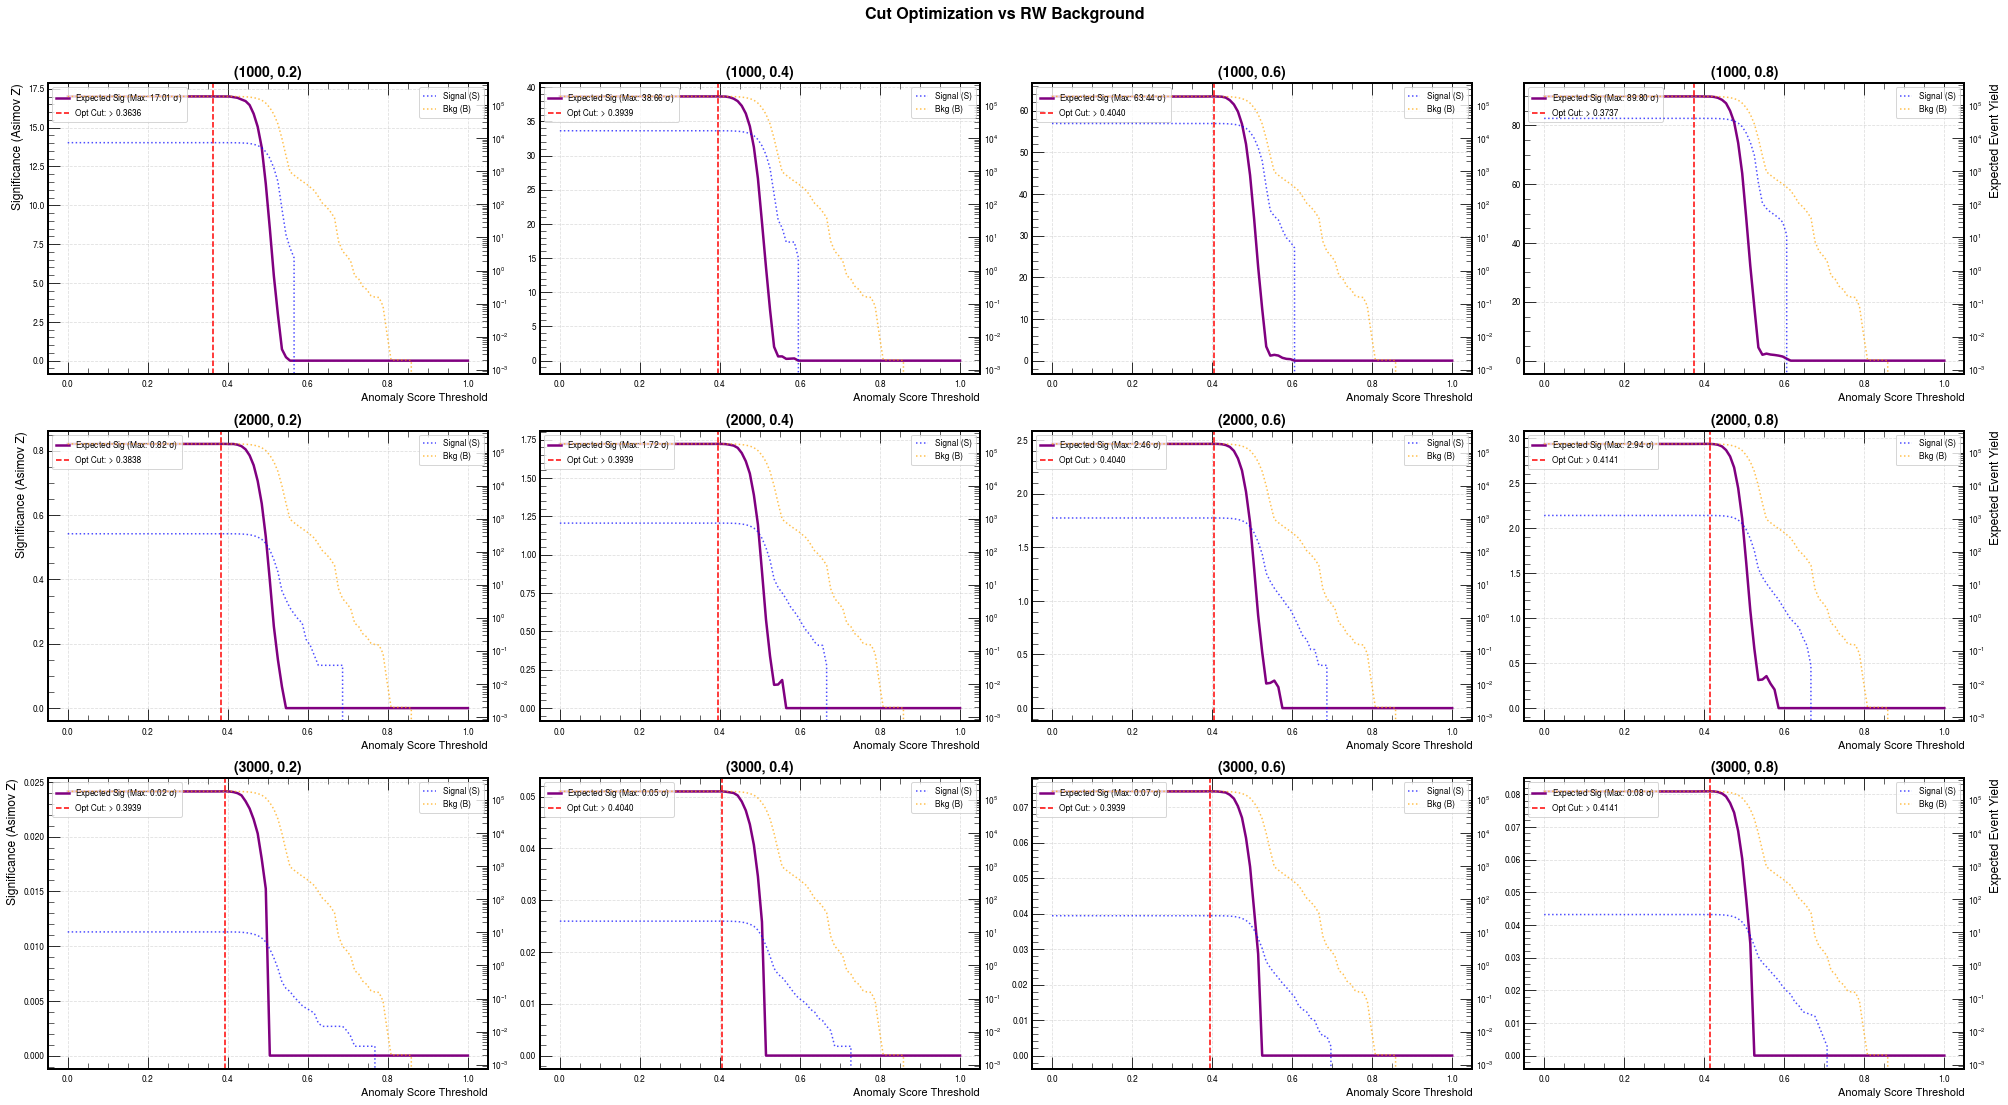

-------------------------------------------------------
OPTIMAL CUT SUMMARY vs RW
-------------------------------------------------------
Signal (1000, 0.2):
  Optimal Threshold : > 0.3636
  Max Significance  : 17.01 sigma
  Expected Signal   : 7334.03
  Expected Bkg      : 183481.38
------------------------------
Signal (1000, 0.4):
  Optimal Threshold : > 0.3939
  Max Significance  : 38.66 sigma
  Expected Signal   : 16801.62
  Expected Bkg      : 183355.44
------------------------------
Signal (1000, 0.6):
  Optimal Threshold : > 0.4040
  Max Significance  : 63.44 sigma
  Expected Signal   : 27816.47
  Expected Bkg      : 183210.81
------------------------------
Signal (1000, 0.8):
  Optimal Threshold : > 0.3737
  Max Significance  : 89.80 sigma
  Expected Signal   : 39783.56
  Expected Bkg      : 183467.13
------------------------------
Signal (2000, 0.2):
  Optimal Threshold : > 0.3838
  Max Significance  : 0.82 sigma
  Expected Signal   : 351.84
  Expected Bkg      : 183426.91
--

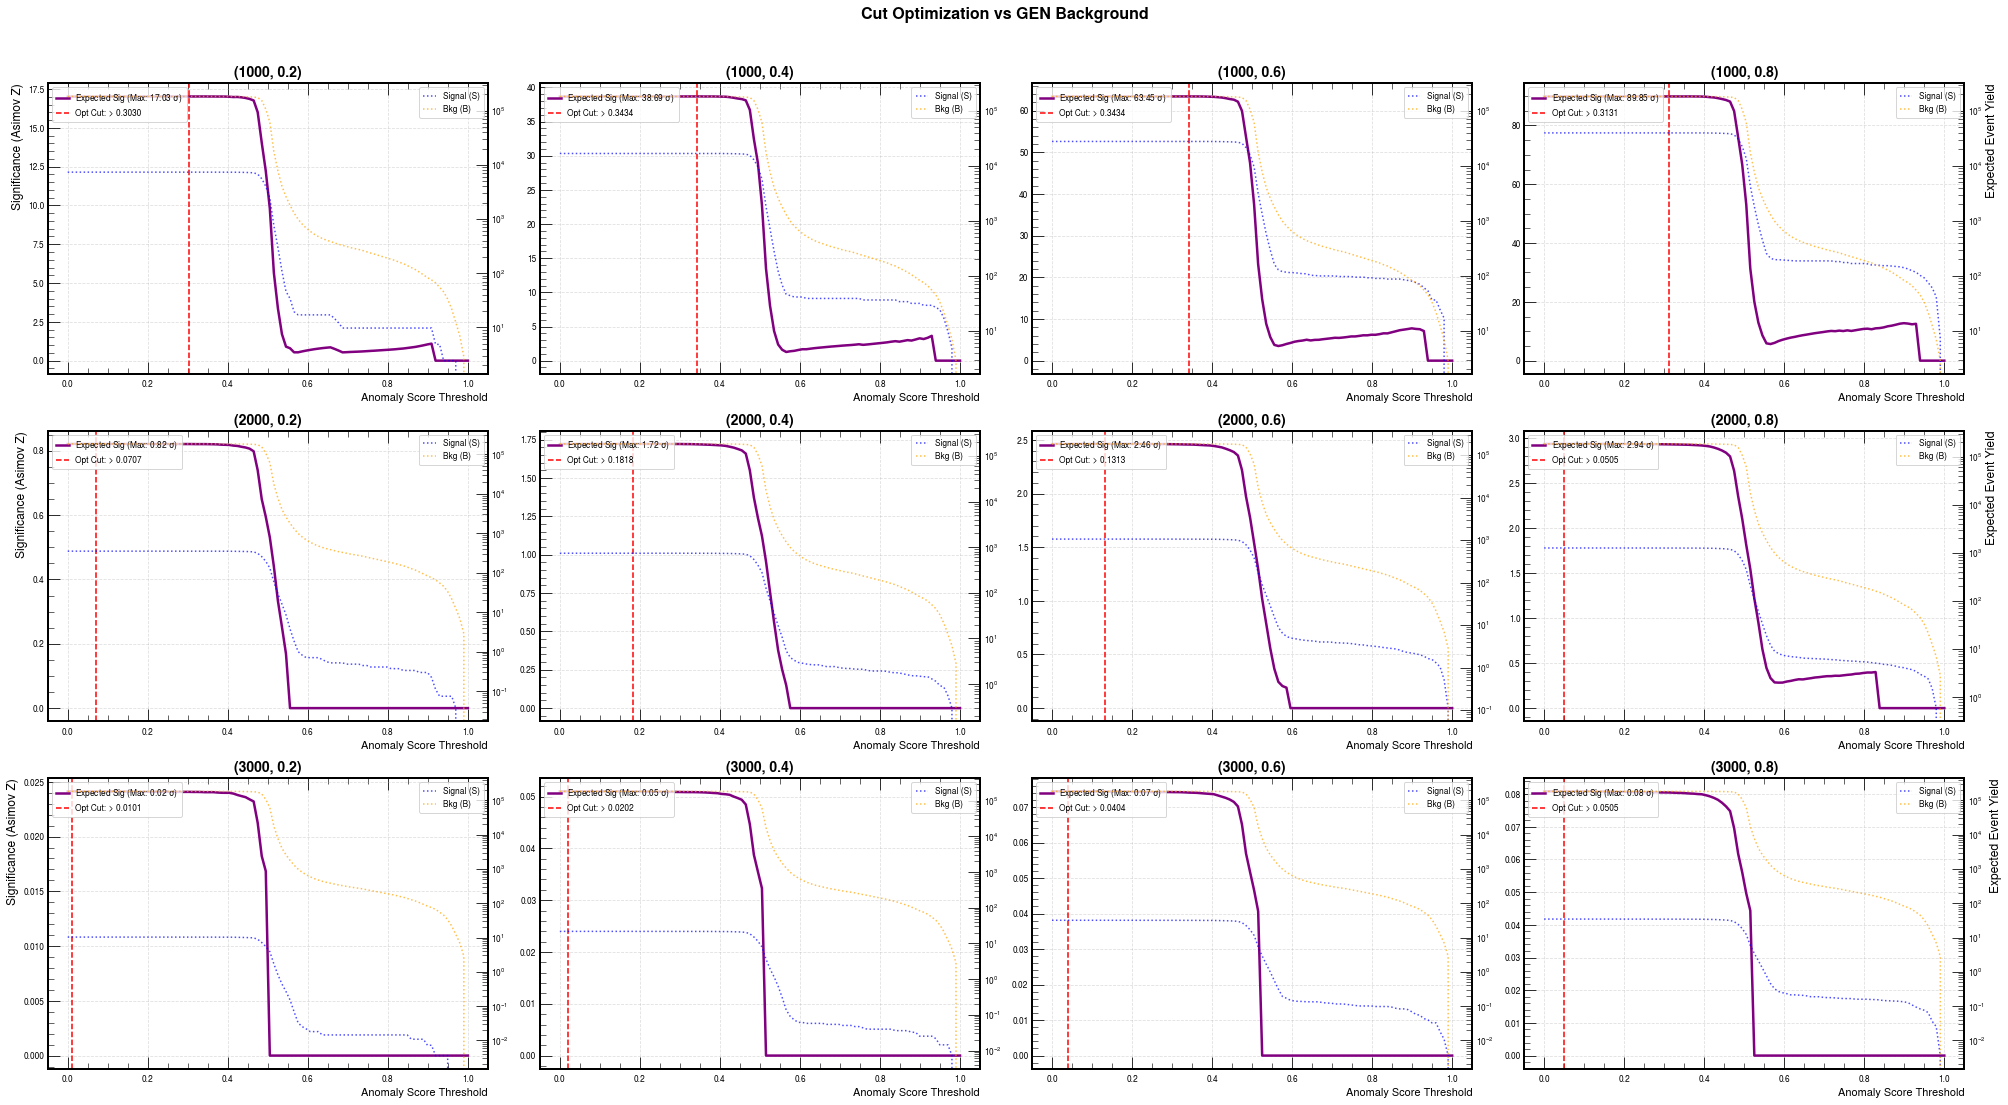

-------------------------------------------------------
OPTIMAL CUT SUMMARY vs GEN
-------------------------------------------------------
Signal (1000, 0.2):
  Optimal Threshold : > 0.3030
  Max Significance  : 17.03 sigma
  Expected Signal   : 7334.03
  Expected Bkg      : 183131.71
------------------------------
Signal (1000, 0.4):
  Optimal Threshold : > 0.3434
  Max Significance  : 38.69 sigma
  Expected Signal   : 16801.62
  Expected Bkg      : 183060.54
------------------------------
Signal (1000, 0.6):
  Optimal Threshold : > 0.3434
  Max Significance  : 63.45 sigma
  Expected Signal   : 27811.62
  Expected Bkg      : 183060.54
------------------------------
Signal (1000, 0.8):
  Optimal Threshold : > 0.3131
  Max Significance  : 89.85 sigma
  Expected Signal   : 39773.86
  Expected Bkg      : 183116.29
------------------------------
Signal (2000, 0.2):
  Optimal Threshold : > 0.0707
  Max Significance  : 0.82 sigma
  Expected Signal   : 351.84
  Expected Bkg      : 183336.99
-

In [ ]:
opt_cut_results = {}
# bkg_type = "RW" # NOM, RW, GEN

for bkg_type in ["NOM", "RW", "GEN"]:
    # for sig_mode in SIGNAL_MODES:
    if bkg_type == "GEN":
        df_mc = df_mc_gen
        min_cut = gen_cut
    elif bkg_type == "RW":
        df_mc = df_mc_rw
        min_cut = rw_cut
    elif bkg_type == "NOM":
        df_mc = df_mc_rw
        min_cut = nom_cut

    opt_cut_results[f"{bkg_type}_{detector_type}"] = optimize_cut_threshold_ver2(df_sig_def, df_mc, bkg_type, SIGNAL_MODES, thres_min=min_cut)


#### Deviation of Data from Background 

In [ ]:
import pyhf
import numpy as np
import scipy.stats

# Optional: Set the pyhf backend to use NumPy for simple CPU execution
pyhf.set_backend("numpy")

def calculate_agnostic_deviation(data_counts, bkg_counts, bkg_stat_unc):
    """
    Calculates the statistical deviation of Data from Background 
    using a model-agnostic generic signal in pyhf.
    """
    
    # 1. Define the Generic Signal (The Data Excess)
    # We cap the minimum at 1e-6 to avoid pyhf errors with absolute zero yields
    generic_signal = [max(d - b, 1e-6) for d, b in zip(data_counts, bkg_counts)]
    
    # If there is absolutely no excess anywhere, return 0 significance
    if sum(generic_signal) <= len(generic_signal) * 1e-6:
        print("No data excess found over background.")
        return 0.5, 0.0, generic_signal

    # 2. Build the pyhf workspace dictionary
    workspace_dict = {
        "channels": [
            {
                "name": "anomaly_region",
                "samples": [
                    {
                        "name": "Generic_Anomaly",
                        "data": generic_signal,
                        "modifiers": [
                            # The signal strength parameter we will test
                            {"name": "mu", "type": "normfactor", "data": None}
                        ]
                    },
                    {
                        "name": "Background",
                        "data": bkg_counts,
                        "modifiers": [
                            # staterror automatically handles independent bin-by-bin 
                            # statistical uncertainties based on your MC weights
                            {
                                "name": "bkg_stat_unc",
                                "type": "staterror",
                                "data": bkg_stat_unc
                            }
                        ]
                    }
                ]
            }
        ],
        "observations": [
            {"name": "anomaly_region", "data": data_counts}
        ],
        "measurements": [
            {"name": "agnostic_test", "config": {"poi": "mu", "mparameters": []}}
        ],
        "version": "1.0.0"
    }

    # 3. Initialize Workspace and Model
    ws = pyhf.Workspace(workspace_dict)
    model = ws.model()
    data = ws.data(model)

    # 4. Perform the Hypothesis Test
    # Testing mu=0 (Background-Only Hypothesis) using the q0 test statistic for discovery
    try:
        result = pyhf.infer.hypotest(
            0.0, data, model, test_stat="q0", return_tail_probs=True
        )
        p0_value = result[1] # result is (CLs_obs, p0_obs) when return_tail_probs=True
    except Exception as e:
        print(f"pyhf fit failed: {e}")
        return None, None, generic_signal

    # 5. Convert p0-value to Gaussian standard deviations (sigma)
    if p0_value < 0.5:
        significance = scipy.stats.norm.isf(p0_value)
    else:
        significance = 0.0

    print("=" * 45)
    print("      MODEL-AGNOSTIC DEVIATION RESULTS     ")
    print("=" * 45)
    print(f"Total Data Events    : {sum(data_counts)}")
    print(f"Total Expected Bkg   : {sum(bkg_counts):.2f}")
    print(f"Integrated Excess    : {sum(generic_signal):.2f}")
    print("-" * 45)
    print(f"Null p0-value        : {p0_value:.4e}")
    print(f"Global Significance  : {significance:.2f} sigma")
    print("=" * 45)

    return p0_value, significance, generic_signal


In [ ]:
def get_poisson_errors(counts):
    """
    Returns asymmetric Garwood/Poisson errors (68.27% CL) for an array of counts.
    Returns an array of shape (2, N) for [error_down, error_up].
    """
    alpha = 1 - 0.682689492 # 1-sigma interval
    lower = np.zeros_like(counts, dtype=float)
    upper = np.zeros_like(counts, dtype=float)
    
    # Lower bound is 0 for 0 counts, otherwise calculated via chi2
    mask = counts > 0
    lower[mask] = 0.5 * stats.chi2.ppf(alpha / 2, 2 * counts[mask])
    
    # Upper bound is well-defined for all counts, including 0
    upper = 0.5 * stats.chi2.ppf(1 - alpha / 2, 2 * (counts + 1))
    
    # Matplotlib error bars require relative distances from the central value
    err_down = counts - lower
    err_up = upper - counts
    
    return np.vstack([err_down, err_up])

In [ ]:
def plot_all_features_post_cut(df_data, df_bkg, threshold, score_col_data, score_col_bkg, bkg_weight_col, bkg_type, closure):
    # 1. Apply the cut
    if closure == "HIGH":
        mask_data = df_data[score_col_data] > threshold
        mask_bkg = df_bkg[score_col_bkg] > threshold
    elif closure == "LOW":
        mask_data = df_data[score_col_data] < threshold
        mask_bkg = df_bkg[score_col_bkg] < threshold
    
    print(f"Data passing cut: {mask_data.sum()}")
    print(f"Bkg passing cut:  {mask_bkg.sum()}")

    # 2. Features mapping
    features = {
        'mjj':           {"bins": np.linspace(0, 4000, 21), "label": "Invariant Mass $m_{jj}$ [GeV]", "log": True, "unit": "GeV"},
        'met_recalc_pt': {"bins": np.linspace(400, 4000, 21), "label": "$E_{T}^{\\mathrm{miss}}$ [GeV]", "log": True, "unit": "GeV"},
        'ht':            {"bins": np.linspace(400, 4000, 21), "label": "$H_T$ [GeV]", "log": True, "unit": "GeV"},
        'ljet1_tau21':   {"bins": np.linspace(0, 1, 21),      "label": "Leading Jet $\\tau_{21}$", "log": False, "unit": None},
        'ljet1_tau32':   {"bins": np.linspace(0, 1, 21),      "label": "Leading Jet $\\tau_{32}$", "log": False, "unit": None},
        'ljet2_tau21':   {"bins": np.linspace(0, 1, 21),      "label": "Subleading Jet $\\tau_{21}$", "log": False, "unit": None},
        'ljet2_tau32':   {"bins": np.linspace(0, 1, 21),      "label": "Subleading Jet $\\tau_{32}$", "log": False, "unit": None}
    }

    fig = plt.figure(figsize=(8*10, 8))
    outer_grid = gridspec.GridSpec(1, 8, wspace=0.3, hspace=0.3)

    for i, (feat, info) in enumerate(features.items()):
        bins = info["bins"]
        bin_width = bins[1] - bins[0]
        
        # Clip data to max/min bin edges (Handle Overflow)
        data_var = np.clip(df_data.loc[mask_data, feat], bins[0], bins[-1])
        bkg_var = np.clip(df_bkg.loc[mask_bkg, feat], bins[0], bins[-1])
        bkg_weights = df_bkg.loc[mask_bkg, bkg_weight_col]
        
        data_counts, _ = np.histogram(data_var, bins=bins)
        bkg_counts, _  = np.histogram(bkg_var, bins=bins, weights=bkg_weights)
        bkg_var_counts, _ = np.histogram(bkg_var, bins=bins, weights=bkg_weights**2)
        

        bkg_stat_unc = np.sqrt(bkg_var_counts)
        data_poisson_err = get_poisson_errors(data_counts) # NEW: Asymmetric data errors

        inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[i], height_ratios=[3, 1], hspace=0.08)
        ax_main = fig.add_subplot(inner_grid[0])
        ax_ratio = fig.add_subplot(inner_grid[1], sharex=ax_main)
        
        # --- Main Plot ---
        hep.histplot(bkg_counts, bins=bins, ax=ax_main, histtype='fill', 
                     color='cornflowerblue', label=f'Expected {bkg_type}', edgecolor='black')
        
        ax_main.stairs(
            values=bkg_counts + bkg_stat_unc, 
            baseline=bkg_counts - bkg_stat_unc, 
            edges=bins, 
            fill=True, hatch='////', color='gray', alpha=0.4, label='Bkg Stat Unc'
        )

        hep.histplot(data_counts, bins=bins, ax=ax_main, histtype='errorbar', 
                     color='black', label='Data', yerr=data_poisson_err) 

        ylabel = f"Events / {bin_width:.2g} {info['unit']}" if info['unit'] else f"Events / {bin_width:.2g}"
        ax_main.set_ylabel(ylabel)
        ax_main.legend(loc='upper right', frameon=False, fontsize=14)
        ax_main.tick_params(labelbottom=False)
        
        if info["log"]:
            ax_main.set_yscale('log')
            ax_main.set_ylim(0.1, max(np.max(data_counts), np.max(bkg_counts)) * 10)
        else:
            ax_main.set_ylim(0, max(np.max(data_counts), np.max(bkg_counts)) * 1.5)
            
        region_text = (
            "SR $E_{T}^{\\mathrm{miss}} > 600$ GeV, $H_T > 600$ GeV\n"
            f"Score {'>' if closure=='HIGH' else '<'} {threshold:.2f}"
        )
        ax_main.text(0.05, 0.95, region_text, transform=ax_main.transAxes, 
                     fontsize=14, verticalalignment='top')

        ratio = np.divide(data_counts, bkg_counts, out=np.ones_like(data_counts, dtype=float), where=(bkg_counts>0))

        ratio_poisson_err = np.zeros_like(data_poisson_err)
        valid_bkg = bkg_counts > 0
        ratio_poisson_err[0, valid_bkg] = data_poisson_err[0, valid_bkg] / bkg_counts[valid_bkg] # Down errors
        ratio_poisson_err[1, valid_bkg] = data_poisson_err[1, valid_bkg] / bkg_counts[valid_bkg] # Up errors
        
        hep.histplot(ratio, bins=bins, ax=ax_ratio, histtype='errorbar', color='black', yerr=ratio_poisson_err)
        
        rel_bkg_unc = np.divide(bkg_stat_unc, bkg_counts, out=np.zeros_like(bkg_stat_unc, dtype=float), where=(bkg_counts>0))
        ax_ratio.stairs(
            values=1 + rel_bkg_unc, 
            baseline=1 - rel_bkg_unc, 
            edges=bins, 
            fill=True, hatch='////', color='gray', alpha=0.4
        )
        
        ax_ratio.axhline(1, color='black', linestyle='--', linewidth=1)
        ax_ratio.set_xlabel(info["label"])
        ax_ratio.set_ylabel("Data / Bkg", fontsize=14)
        ax_ratio.set_ylim(0.5, 1.5)
        ax_ratio.set_yticks([0.5, 0.75, 1.0, 1.25, 1.5])

    plt.tight_layout()
    plt.show()

def plot_coarse_major_blocks(df_data, df_bkg, threshold, score_col_data, score_col_bkg, bkg_weight_col, closure):
    # 1. Apply the ML Filter
    if closure == "HIGH":
            mask_data = df_data[score_col_data] > threshold
            mask_bkg = df_bkg[score_col_bkg] > threshold
    elif closure == "LOW":
        mask_data = df_data[score_col_data] < threshold
        mask_bkg = df_bkg[score_col_bkg] < threshold
    
    # 2. Define the EXACT coarse bin edges for each feature
    features = {
        'mjj': {
            'bins': np.array([400, 1000, 2000, 3000, 4000]), 
            'log': True, 
            'title': 'Invariant Mass $m_{jj}$ [GeV]'
        },
        'ljet1_tau21': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Leading Jet $\\tau_{21}$'
        },
        'ljet1_tau32': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Leading Jet $\\tau_{32}$'
        },
        'ljet2_tau21': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Subleading Jet $\\tau_{21}$'
        },
        'ljet2_tau32': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Subleading Jet $\\tau_{32}$'
        }
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, (feat, info) in enumerate(features.items()):
        ax = axes[i]
        bins = info['bins']
        
        # Extract filtered feature arrays
        data_var = df_data.loc[mask_data, feat]
        bkg_var = df_bkg.loc[mask_bkg, feat]
        bkg_weights = df_bkg.loc[mask_bkg, bkg_weight_col]
        
        # Calculate histograms using the DIRECT coarse bin edges
        data_counts, _ = np.histogram(data_var, bins=bins)
        bkg_counts, _ = np.histogram(bkg_var, bins=bins, weights=bkg_weights)
        bkg_var_counts, _ = np.histogram(bkg_var, bins=bins, weights=bkg_weights**2)
        bkg_stat_unc = np.sqrt(bkg_var_counts)
        
        bin_centers = (bins[:-1] + bins[1:]) / 2
        bin_widths = np.diff(bins)
        
        # 1. Plot Expected Background as wide blocks matching coarse bin widths
        ax.bar(bin_centers, bkg_counts, width=bin_widths, color='cornflowerblue', 
               alpha=0.7, edgecolor='navy', label='Expected Bkg')
        
        # 2. Background MC Uncertainty band
        ax.bar(bin_centers, 2 * bkg_stat_unc, width=bin_widths, bottom=bkg_counts - bkg_stat_unc, 
               alpha=0.3, color='gray', hatch='////', label='MC Stat. Unc.')
        
        # 3. Plot Data as points centered inside each coarse bin block
        ax.errorbar(bin_centers, data_counts, yerr=np.sqrt(data_counts), 
                    fmt='ko', label='Observed Data', capsize=0, elinewidth=1.5, markersize=5)
        
        # Set explicit tick marks on the axis showing exact bin boundaries
        ax.set_xticks(bins)
        
        ax.set_title(info['title'], fontsize=12, fontweight='bold')
        ax.set_ylabel("Events / Bin")
        
        # Y-axis scaling
        if info['log']:
            ax.set_yscale('log')
            max_y = max(np.max(data_counts), np.max(bkg_counts)) * 10
            min_y = max(0.1, np.min(bkg_counts[bkg_counts > 0]) * 0.5) if len(bkg_counts[bkg_counts > 0]) > 0 else 0.1
            ax.set_ylim(min_y, max_y)
        else:
            max_y = max(np.max(data_counts), np.max(bkg_counts)) * 1.3
            ax.set_ylim(0, max_y)
            
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.4)

    # Hide the 6th empty subplot
    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.show()

def visualize_5d_major_blocks(df_data, df_bkg, threshold, score_col_data, score_col_bkg, bkg_weight_col, closure):
    # 1. Apply the ML Filter
    if closure == "HIGH":
            mask_data = df_data[score_col_data] > threshold
            mask_bkg = df_bkg[score_col_bkg] > threshold
    elif closure == "LOW":
        mask_data = df_data[score_col_data] < threshold
        mask_bkg = df_bkg[score_col_bkg] < threshold
    
    # 2. Define the features and their major block boundaries (the coarse bins)
    features = {
        'mjj': {
            'edges': [400, 1000, 2000, 3000, 4000], 
            'plot_range': (400, 4000), 'log': True, 'title': 'Invariant Mass $m_{jj}$',
            'bins': np.arange(0, 4200, 200)
        },
        'ljet1_tau21': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Leading Jet $\\tau_{21}$',
            'bins': np.arange(0, 1.25, 0.25)
        },
        'ljet1_tau32': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Leading Jet $\\tau_{32}$',
            'bins': np.arange(0, 1.25, 0.25)
        },
        'ljet2_tau21': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Subleading Jet $\\tau_{21}$',
            'bins': np.arange(0, 1.25, 0.25)
        },
        'ljet2_tau32': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Subleading Jet $\\tau_{32}$',
            'bins': np.arange(0, 1.25, 0.25)
        }
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, (feat, info) in enumerate(features.items()):
        ax = axes[i]
        
        # We use fine binning just for the visual background/data shapes
        fine_bins = info['bins']
        
        # Extract data
        data_var = df_data.loc[mask_data, feat]
        bkg_var = df_bkg.loc[mask_bkg, feat]
        bkg_weights = df_bkg.loc[mask_bkg, bkg_weight_col]
        
        # Plot Expected Background
        ax.hist(bkg_var, bins=fine_bins, weights=bkg_weights, 
                color='cornflowerblue', alpha=0.7, label='Expected Bkg')
        
        # Plot Observed Data
        data_counts, _ = np.histogram(data_var, bins=fine_bins)
        bin_centers = (fine_bins[:-1] + fine_bins[1:]) / 2
        ax.errorbar(bin_centers, data_counts, yerr=np.sqrt(data_counts), 
                    fmt='ko', label='Observed Data', markersize=4)
        
        # Overlay the Major Block Bin Boundaries
        for edge in info['edges']:
            ax.axvline(edge, color='red', linestyle='--', linewidth=2, alpha=0.8)
            
        ax.set_title(info['title'], fontsize=12, fontweight='bold')
        ax.set_ylabel("Events")
        if info['log']:
            ax.set_yscale('log')
        ax.legend()

    # Hide the 6th empty subplot
    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.show()

Data passing cut: 5014
Bkg passing cut:  65939


/tmp/ipykernel_655970/1805124053.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


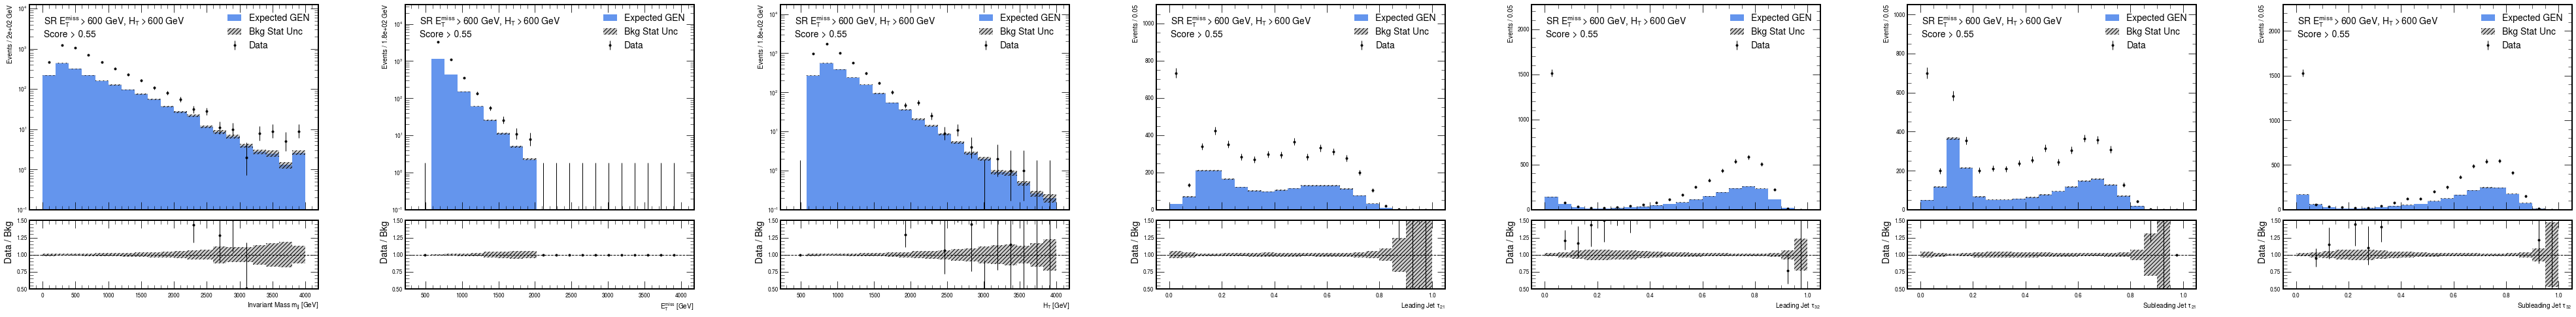

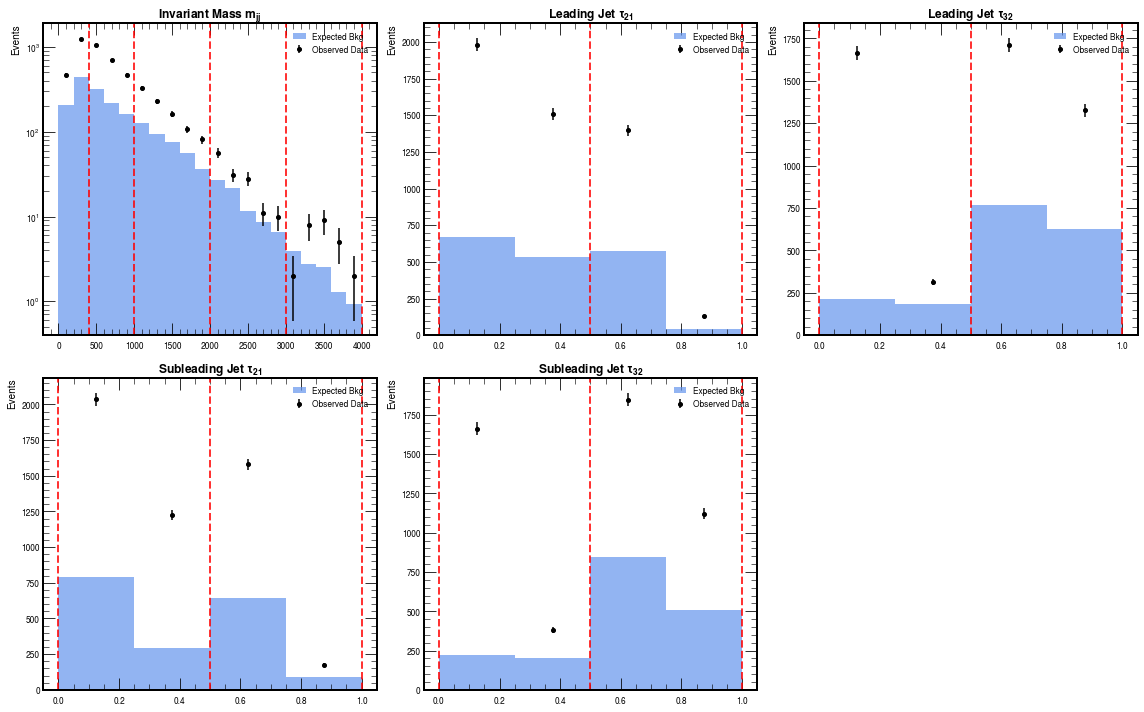

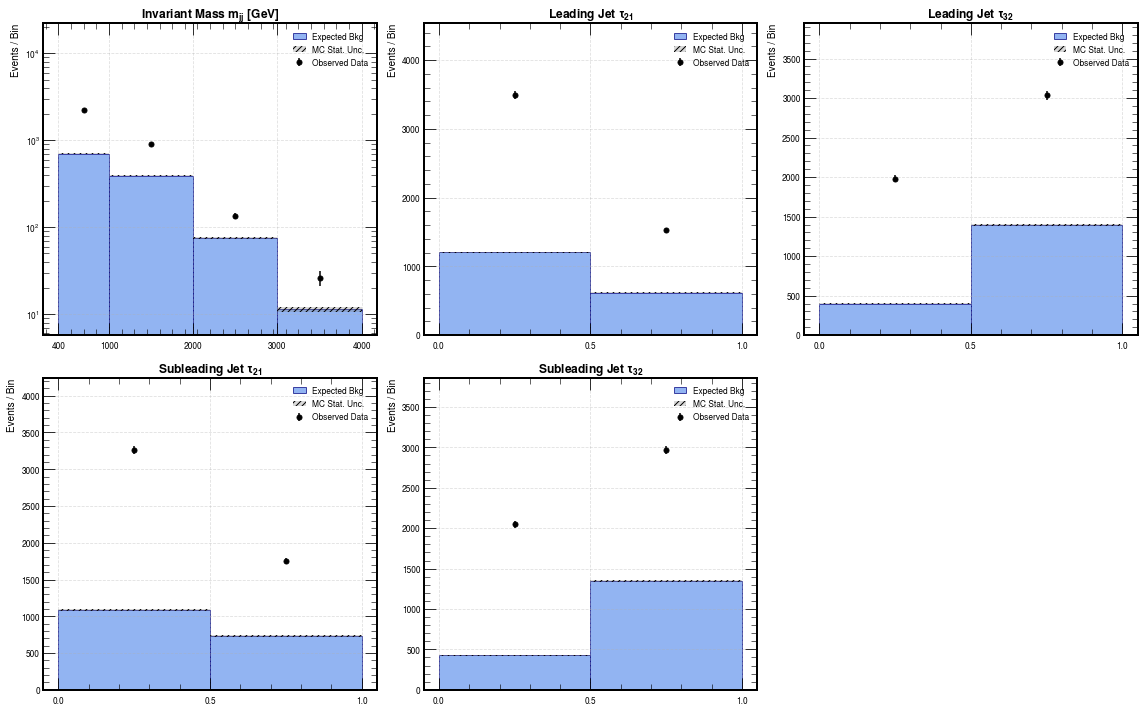

In [ ]:
bkg_type = "GEN"
closure = "HIGH"
if bkg_type == "NOM":
    data_col_score = "score_vs_nominal"
    bkg_col_score = "score_vs_data"
    sig_col_score = "bsm_score_Nom"
    bkg_weight_name = "final_weight"
    anomaly_threshold = nom_cut
    df_bkg = df_mc_rw
elif bkg_type == "RW":
    data_col_score = "score_vs_reweighted"
    bkg_col_score = "score_vs_reweighted_data"
    sig_col_score = "bsm_score_Reweight_Median"
    bkg_weight_name = "rw_mediam_weights"
    anomaly_threshold = rw_cut
    df_bkg = df_mc_rw
elif bkg_type == "GEN":
    data_col_score = "score_vs_generate"
    bkg_col_score = "score_vs_data"
    sig_col_score = "bsm_score_Generate_Combined"
    bkg_weight_name = "total_weight"
    anomaly_threshold = gen_cut
    df_bkg = df_mc_gen
else:
    raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")


df_data_unscaled = transform(df_data, scale=False)
df_bkg_unscaled = transform(df_bkg, scale=False)


plot_all_features_post_cut(
    df_data=df_data_unscaled, 
    df_bkg=df_bkg_unscaled, 
    threshold=anomaly_threshold, 
    score_col_data=data_col_score, 
    score_col_bkg=bkg_col_score, 
    bkg_weight_col=bkg_weight_name,
    bkg_type=bkg_type,
    closure = closure
)

visualize_5d_major_blocks(
    df_data=df_data_unscaled, 
    df_bkg=df_bkg_unscaled, 
    threshold=anomaly_threshold, 
    score_col_data=data_col_score, 
    score_col_bkg=bkg_col_score, 
    bkg_weight_col=bkg_weight_name,
    closure = closure
)

plot_coarse_major_blocks(
    df_data=df_data_unscaled, 
    df_bkg=df_bkg_unscaled, 
    threshold=anomaly_threshold, 
    score_col_data=data_col_score, 
    score_col_bkg=bkg_col_score, 
    bkg_weight_col=bkg_weight_name,
    closure = closure
)



# # 3. Run the Agnostic Deviation Test
# p0, sigma, gen_sig = calculate_agnostic_deviation(
#     data_counts=data_counts_list, 
#     bkg_counts=bkg_counts_list, 
#     bkg_stat_unc=bkg_stat_unc_list
# )

In [ ]:
import pyhf
import numpy as np
import pandas as pd
import operator
import warnings

def find_limit_1d(mu_scan, cls_values, threshold=0.05):
    """Interpolates the mu value where CLs crosses 0.05."""
    valid = ~np.isnan(cls_values)
    if np.sum(valid) < 2:
        return np.nan
        
    m = np.array(mu_scan)[valid]
    c = np.array(cls_values)[valid]
    
    # If the limit never crossed 0.05, return NaN instead of a false 10.0
    if np.min(c) > threshold:
        return np.nan
        
    idx = np.argsort(c)
    return np.interp(threshold, c[idx], m[idx])

def calculate_pyhf_limits(
    df_sig_dict, 
    signal_modes, 
    df_mc, 
    df_data, 
    bkg_type, 
    score_cuts, 
    df_meta,
    mjj_bins, 
    mjj_col="mjj",
    bkg_syst_frac=0.10, 
    lumi_unc_frac=0.017, 
    cut_direction="greater"
):
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    pyhf.set_backend("numpy")
    
    if bkg_type == "NOM":
        data_col_score = "score_vs_nominal"
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Nom"
        bkg_weight_name = "final_weight"
        apply_lumi_to_bkg = True 
    elif bkg_type == "RW":
        data_col_score = "score_vs_reweighted"
        bkg_col_score = "score_vs_reweighted_data"
        sig_col_score = "bsm_score_Reweight_Median"
        bkg_weight_name = "rw_mediam_weights"
        apply_lumi_to_bkg = False 
    elif bkg_type == "GEN":
        data_col_score = "score_vs_generate"
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Generate_Combined"
        bkg_weight_name = "total_weight"
        apply_lumi_to_bkg = False 
    else:
        raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")

    op = operator.gt if cut_direction == "greater" else operator.lt
    results = []

    print(f"--- Running Shape Analysis pyhf Limits for Background: {bkg_type} ---")
    
    for sig_mode in signal_modes:
        df_sig = df_sig_dict[sig_mode]
        mass = int(sig_mode.split("_")[0])
        rinv_val = int(sig_mode.split("_")[1])
        meta_row = df_meta[(df_meta['Mass'] == mass) & (df_meta['Rinv'] == rinv_val)]
        
        if meta_row.empty:
            continue
            
        xs_nom = meta_row.iloc[0]['XS']
        theory_unc = meta_row.iloc[0]['TheoryUnc']
        
        if isinstance(score_cuts, dict):
            cut = score_cuts.get(sig_mode)
            if isinstance(cut, dict): 
                cut = cut.get('opt_thresh', score_cuts.get(sig_mode))
        else:
            cut = float(score_cuts)

        pass_sig = df_sig[op(df_sig[sig_col_score], cut)].copy()
        pass_bkg = df_mc[op(df_mc[bkg_col_score], cut)].copy()
        pass_data = df_data[op(df_data[data_col_score], cut)].copy()
        
        if len(pass_sig) == 0 or len(pass_bkg) == 0:
            print(f"  [{sig_mode}] Zero events passed cut. Skipping.")
            continue
            
        pass_sig_unscaled = transform(pass_sig, scale=False)
        pass_bkg_unscaled = transform(pass_bkg, scale=False)
        pass_data_unscaled = transform(pass_data, scale=False)
        
        sig_mjj = pass_sig_unscaled[mjj_col].to_numpy()
        sig_w   = pass_sig_unscaled["final_weight"].to_numpy()
        bkg_mjj = pass_bkg_unscaled[mjj_col].to_numpy()
        bkg_w   = pass_bkg_unscaled[bkg_weight_name].to_numpy()
        data_mjj = pass_data_unscaled[mjj_col].to_numpy()
        
        hist_sig, _ = np.histogram(sig_mjj, bins=mjj_bins, weights=sig_w)
        hist_bkg, _ = np.histogram(bkg_mjj, bins=mjj_bins, weights=bkg_w)
        hist_data, _ = np.histogram(data_mjj, bins=mjj_bins)
        hist_bkg_var, _ = np.histogram(bkg_mjj, bins=mjj_bins, weights=bkg_w**2)

        total_s = np.sum(hist_sig)
        total_b = np.sum(hist_bkg)
        total_d = np.sum(hist_data)

        if total_s <= 0:
            print(f"  [{sig_mode}] Signal yield <= 0. Skipping.")
            continue
            
        # ---------------------------------------------------------
        # FIX 1: STABILIZE BINS
        # Force a baseline physics floor (1e-4) so the optimizer 
        # gradient never divides by zero if Data > 0 in an empty bin.
        # ---------------------------------------------------------
        epsilon = 1e-4
        hist_bkg_safe = np.maximum(hist_bkg, epsilon)
        hist_bkg_var_safe = np.maximum(hist_bkg_var, epsilon)
        hist_sig_safe = np.clip(hist_sig, 0.0, None) 

        bkg_modifiers = [
            {"name": "stat_uncert", "type": "staterror", "data": np.sqrt(hist_bkg_var_safe).tolist()},
            {"name": "bkg_syst", "type": "normsys", "data": {"hi": 1.0 + bkg_syst_frac, "lo": max(1.0 - bkg_syst_frac, 0.001)}}
        ]
        
        sig_modifiers = [
            {"name": "mu", "type": "normfactor", "data": None},
            {"name": "sig_theory_unc", "type": "normsys", "data": {"hi": 1.0 + theory_unc, "lo": max(1.0 - theory_unc, 0.001)}}
        ]
        
        if apply_lumi_to_bkg:
            bkg_modifiers.append({"name": "lumi_unc", "type": "normsys", "data": {"hi": 1.0 + lumi_unc_frac, "lo": max(1.0 - lumi_unc_frac, 0.001)}})
            sig_modifiers.append({"name": "lumi_unc", "type": "normsys", "data": {"hi": 1.0 + lumi_unc_frac, "lo": max(1.0 - lumi_unc_frac, 0.001)}})
        else:
            sig_modifiers.append({"name": "lumi_unc", "type": "normsys", "data": {"hi": 1.0 + lumi_unc_frac, "lo": max(1.0 - lumi_unc_frac, 0.001)}})

        # ---------------------------------------------------------
        # FIX 2: DYNAMIC MU MAX
        # Calculate exactly how high the data pushes the observed mu,
        # then set the scan maximum appropriately.
        # ---------------------------------------------------------
        approx_mu_exp = 2.0 * np.sqrt(total_b + 1.0) / max(total_s, 1e-5)
        approx_mu_obs = max(total_d - total_b, 0.0) / max(total_s, 1e-5)
        
        # Max of: 10, the expected limit * 10, or the observed excess * 5
        mu_max = max(10.0, approx_mu_exp * 10.0, approx_mu_obs * 5.0)
        mu_max = min(mu_max, 500000.0) # Hard safety cap
        
        spec = {
            "channels": [{"name": "SR_mjj", "samples": [
                {
                    "name": "signal", 
                    "data": hist_sig_safe.tolist(),
                    "modifiers": sig_modifiers
                },
                {
                    "name": "background", 
                    "data": hist_bkg_safe.tolist(), 
                    "modifiers": bkg_modifiers
                }
            ]}],
            "observations": [{"name": "SR_mjj", "data": hist_data.tolist()}],
            "measurements": [
                {
                    "name": "Measurement", 
                    "config": {
                        "poi": "mu", 
                        "parameters": [{"name": "mu", "bounds": [[0.0, mu_max * 1.5]]}]
                    }
                }
            ],
            "version": "1.0.0"
        }

        workspace = pyhf.Workspace(spec)
        model = workspace.model()
        data_ws = workspace.data(model)

        # We use geomspace to densely sample small numbers while still reaching the huge ones
        mu_scan = np.geomspace(0.01, mu_max, 60)
        obs_cls_list, exp_cls_list = [], []
        
        for mu_val in mu_scan:
            try:
                obs, exp = pyhf.infer.hypotest(
                    float(mu_val), data_ws, model, test_stat="qtilde", return_expected_set=True
                )
                obs_cls_list.append(float(obs))
                exp_cls_list.append([float(e) for e in exp])
            except Exception:
                # Silently catch optimizer instability at extreme values
                obs_cls_list.append(np.nan)
                exp_cls_list.append([np.nan]*5)
                
        obs_cls = np.array(obs_cls_list)
        exp_cls_set = np.array(exp_cls_list).T

        obs_limit = find_limit_1d(mu_scan, obs_cls)
        exp_m2    = find_limit_1d(mu_scan, exp_cls_set[0])
        exp_m1    = find_limit_1d(mu_scan, exp_cls_set[1])
        exp_limit = find_limit_1d(mu_scan, exp_cls_set[2])
        exp_p1    = find_limit_1d(mu_scan, exp_cls_set[3])
        exp_p2    = find_limit_1d(mu_scan, exp_cls_set[4])
        
        results.append({
            "Mass": mass, "Rinv": rinv_val, "Cut": cut,
            "Obs_Limit_XS": obs_limit * xs_nom if not np.isnan(obs_limit) else np.nan,
            "Exp_Limit_XS": exp_limit * xs_nom if not np.isnan(exp_limit) else np.nan,
            "Exp_m2_XS": exp_m2 * xs_nom if not np.isnan(exp_m2) else np.nan,
            "Exp_m1_XS": exp_m1 * xs_nom if not np.isnan(exp_m1) else np.nan,
            "Exp_p1_XS": exp_p1 * xs_nom if not np.isnan(exp_p1) else np.nan,
            "Exp_p2_XS": exp_p2 * xs_nom if not np.isnan(exp_p2) else np.nan,
            "S_yield": total_s, "B_yield": total_b, "D_yield": total_d
        })
        
        print(f"  [{sig_mode}] Exp Limit (mu): {exp_limit:.4f}  |  Obs Limit (mu): {obs_limit:.4f}")

    return pd.DataFrame(results)

In [ ]:
from scipy.interpolate import griddata
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_2d_brazilian(df_limits, df_meta, bkg_type):
    """
    Generates a publication-quality 2D Brazilian exclusion plot (Mass vs Rinv).
    Draws contours where the signal strength upper limit = 1.0.
    """
    hep.style.use(hep.style.ROOT) 
    
    # Merge limits with metadata to access Theory XS
    df_plot = pd.merge(df_limits, df_meta, on=["Mass", "Rinv"])
    
    # Calculate Signal Strength (mu). If mu <= 1.0, the region is excluded.
    for col in ['Obs_Limit_XS', 'Exp_Limit_XS', 'Exp_m2_XS', 'Exp_m1_XS', 'Exp_p1_XS', 'Exp_p2_XS']:
        new_col = col.replace('_XS', '_mu')
        df_plot[new_col] = df_plot[col] / df_plot['XS']
        
    # Convert Rinv to physical decimal values (e.g., 2 -> 0.2) for standard HEP plotting
    df_plot['Rinv_dec'] = df_plot['Rinv'] / 10.0
    
    # Create a dense grid for smooth contours
    xi = np.linspace(df_plot['Mass'].min(), df_plot['Mass'].max(), 300)
    yi = np.linspace(df_plot['Rinv_dec'].min(), df_plot['Rinv_dec'].max(), 300)
    X, Y = np.meshgrid(xi, yi)
    
    points = (df_plot['Mass'].values, df_plot['Rinv_dec'].values)
    
    # Interpolate mu values onto the dense grid
    # method='cubic' generates smooth continuous curves standard in HEP
    try:
        Z_exp = griddata(points, df_plot['Exp_Limit_mu'].values, (X, Y), method='cubic')
        Z_obs = griddata(points, df_plot['Obs_Limit_mu'].values, (X, Y), method='cubic')
        Z_m1  = griddata(points, df_plot['Exp_m1_mu'].values, (X, Y), method='cubic')
        Z_p1  = griddata(points, df_plot['Exp_p1_mu'].values, (X, Y), method='cubic')
        Z_m2  = griddata(points, df_plot['Exp_m2_mu'].values, (X, Y), method='cubic')
        Z_p2  = griddata(points, df_plot['Exp_p2_mu'].values, (X, Y), method='cubic')
    except Exception:
        # Fallback to linear if cubic geometry fails (due to sparse points)
        Z_exp = griddata(points, df_plot['Exp_Limit_mu'].values, (X, Y), method='linear')
        Z_obs = griddata(points, df_plot['Obs_Limit_mu'].values, (X, Y), method='linear')
        Z_m1  = griddata(points, df_plot['Exp_m1_mu'].values, (X, Y), method='linear')
        Z_p1  = griddata(points, df_plot['Exp_p1_mu'].values, (X, Y), method='linear')
        Z_m2  = griddata(points, df_plot['Exp_m2_mu'].values, (X, Y), method='linear')
        Z_p2  = griddata(points, df_plot['Exp_p2_mu'].values, (X, Y), method='linear')

    # Create categorical map for the uncertainty bands
    # A point is inside the 2-sigma band if its limit could cross 1.0 within +/- 2 sigma.
    # Ergo: (Z_m2 <= 1.0) AND (Z_p2 >= 1.0)
    C = np.zeros_like(Z_exp)
    C[(Z_m2 <= 1.0) & (Z_p2 >= 1.0)] = 1
    C[(Z_m1 <= 1.0) & (Z_p1 >= 1.0)] = 2
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 1. Plot the Green and Yellow bands
    ax.contourf(X, Y, C, levels=[0.5, 1.5, 2.5], colors=['#FDC536', '#4AD928'], alpha=0.9)
    
    # 2. Draw the primary exclusion boundary lines where limit == 1.0
    ax.contour(X, Y, Z_exp, levels=[1.0], colors='black', linestyles='dashed', linewidths=3)
    ax.contour(X, Y, Z_obs, levels=[1.0], colors='red', linestyles='solid', linewidths=3)
    
    # 3. Add a faint red wash over the actual excluded region (where observed mu < 1.0)
    ax.contourf(X, Y, Z_obs, levels=[0.0, 1.0], colors=['red'], alpha=0.1)
    
    # Plot the original signal mass points as reference markers
    ax.scatter(df_plot['Mass'], df_plot['Rinv_dec'], color='black', marker='o', s=30, zorder=5)
    
    # Custom Legend
    legend_elements = [
        Line2D([0], [0], color='red', lw=3, label='Observed (95% CL)'),
        Line2D([0], [0], color='black', lw=3, linestyle='dashed', label='Expected (95% CL)'),
        Patch(facecolor='#4AD928', edgecolor='none', label=r'Expected $\pm 1\sigma$'),
        Patch(facecolor='#FDC536', edgecolor='none', label=r'Expected $\pm 2\sigma$')
    ]
    ax.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=12)
    
    # Axis formatting
    ax.set_xlabel(r'$M_{\phi}$ [GeV]', fontsize=16)
    ax.set_ylabel(r'$R_{\text{inv}}$', fontsize=16)
    ax.set_xlim(df_plot['Mass'].min(), df_plot['Mass'].max())
    ax.set_ylim(df_plot['Rinv_dec'].min(), df_plot['Rinv_dec'].max())
    
    # Standard HEP Labeling
    # hep.atlas.text("Internal", ax=ax)
    # hep.atlas.label(data=True, lumi=25.4, ax=ax, loc=0)
    hep.atlas.label(exp="", label="", data=True, lumi=25.4, ax=ax, loc=0)
    ax.text(0.05, 0.70, f"BSM Signal Exclusions\nBackground Est: {bkg_type}", 
            transform=ax.transAxes, fontsize=14, 
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    plt.tight_layout()
    plt.show()

In [ ]:
MJJ_BINS = np.arange(0, 5200, 200) 

df_limits_gen = calculate_pyhf_limits(
    df_sig_dict=df_sig_def, 
    signal_modes=SIGNAL_MODES, 
    df_mc=df_mc_gen, 
    df_data=df_data, 
    bkg_type="GEN", 
    score_cuts=opt_cut_results["GEN_default"], 
    df_meta=DF_META,
    mjj_bins=MJJ_BINS, # <-- Added here
    bkg_syst_frac=0.10, 
    cut_direction="greater" # Or "greater" based on your classifier
)

--- Running Shape Analysis pyhf Limits for Background: GEN ---


  [1000_2] Exp Limit (mu): 0.1838  |  Obs Limit (mu): 0.5467
  [1000_4] Exp Limit (mu): 0.0910  |  Obs Limit (mu): 0.2394
  [1000_6] Exp Limit (mu): 0.0606  |  Obs Limit (mu): 0.1517
  [1000_8] Exp Limit (mu): 0.0437  |  Obs Limit (mu): 0.0975
  [2000_2] Exp Limit (mu): 1.5592  |  Obs Limit (mu): 0.6659
  [2000_4] Exp Limit (mu): 0.8285  |  Obs Limit (mu): 0.3113
  [2000_6] Exp Limit (mu): 0.6165  |  Obs Limit (mu): 0.2273
  [2000_8] Exp Limit (mu): 0.5446  |  Obs Limit (mu): 0.2047
  [3000_2] Exp Limit (mu): 36.3659  |  Obs Limit (mu): 14.7836
  [3000_4] Exp Limit (mu): 18.4595  |  Obs Limit (mu): 5.7059
  [3000_6] Exp Limit (mu): 13.0035  |  Obs Limit (mu): 3.9369
  [3000_8] Exp Limit (mu): 11.2443  |  Obs Limit (mu): 3.1744


/tmp/ipykernel_655970/3730156354.py:88: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", label="", data=True, lumi=25.4, ax=ax, loc=0)
/home/aegis/.local/lib/python3.10/site-packages/mplhep/exp_atlas.py:65: FutureWarning: kwarg `label` in function `exp_label()` is deprecated and will be removed: Use `text="..."` instead.
  return label_base.exp_label(**kwargs)


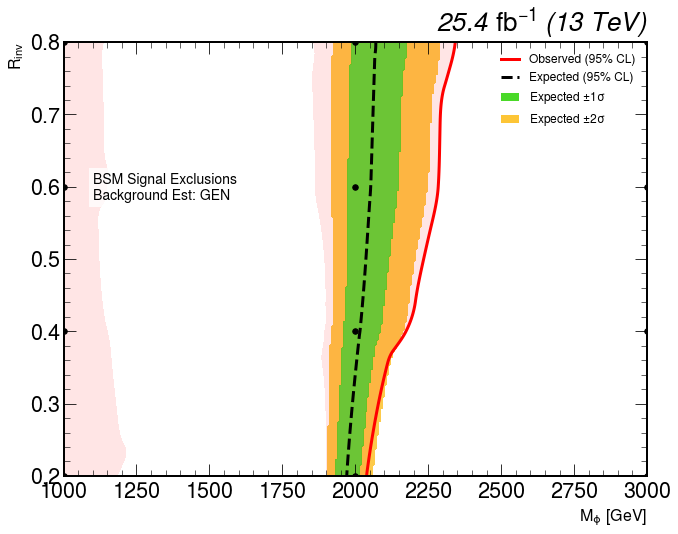

In [ ]:
plot_2d_brazilian(df_limits_gen, DF_META, bkg_type="GEN")

--- Running Shape Analysis pyhf Limits for Background: RW ---
  [1000_2] Exp Limit (mu): 0.2489  |  Obs Limit (mu): 0.0569
  [1000_4] Exp Limit (mu): 0.1229  |  Obs Limit (mu): 0.0268
  [1000_6] Exp Limit (mu): 0.0809  |  Obs Limit (mu): 0.0185
  [1000_8] Exp Limit (mu): 0.0579  |  Obs Limit (mu): 0.0138
  [2000_2] Exp Limit (mu): 2.0605  |  Obs Limit (mu): 1.4272
  [2000_4] Exp Limit (mu): 1.0609  |  Obs Limit (mu): 0.7810
  [2000_6] Exp Limit (mu): 0.7948  |  Obs Limit (mu): 0.6393
  [2000_8] Exp Limit (mu): 0.6937  |  Obs Limit (mu): 0.5922
  [3000_2] Exp Limit (mu): 46.2764  |  Obs Limit (mu): 80.9081
  [3000_4] Exp Limit (mu): 23.3177  |  Obs Limit (mu): 39.9114
  [3000_6] Exp Limit (mu): 16.5016  |  Obs Limit (mu): 27.7107
  [3000_8] Exp Limit (mu): 13.1815  |  Obs Limit (mu): 27.0631


/tmp/ipykernel_655970/3730156354.py:88: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", label="", data=True, lumi=25.4, ax=ax, loc=0)


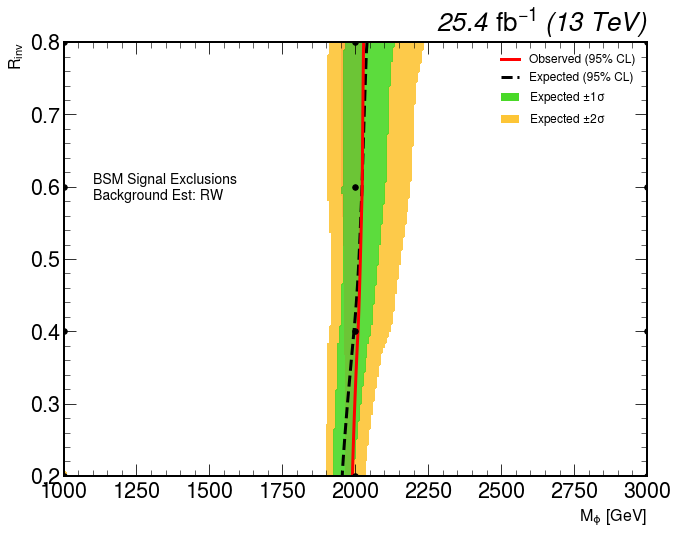

In [ ]:
# Assuming optimal cuts were generated:
df_limits_rw = calculate_pyhf_limits(
    df_sig_dict=df_sig_def, 
    signal_modes=SIGNAL_MODES, 
    df_mc=df_mc_rw, 
    df_data=df_data, 
    bkg_type="RW", 
    score_cuts=opt_cut_results["RW_default"], 
    df_meta=DF_META,
    mjj_bins=MJJ_BINS, # <-- Added here
    bkg_syst_frac=0.10, 
    cut_direction="greater" # Or "greater" based on your classifier
)
# Render the 2D Brazilian plot
plot_2d_brazilian(df_limits_rw, DF_META, bkg_type="RW")

/tmp/ipykernel_655970/3730156354.py:88: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", label="", data=True, lumi=25.4, ax=ax, loc=0)


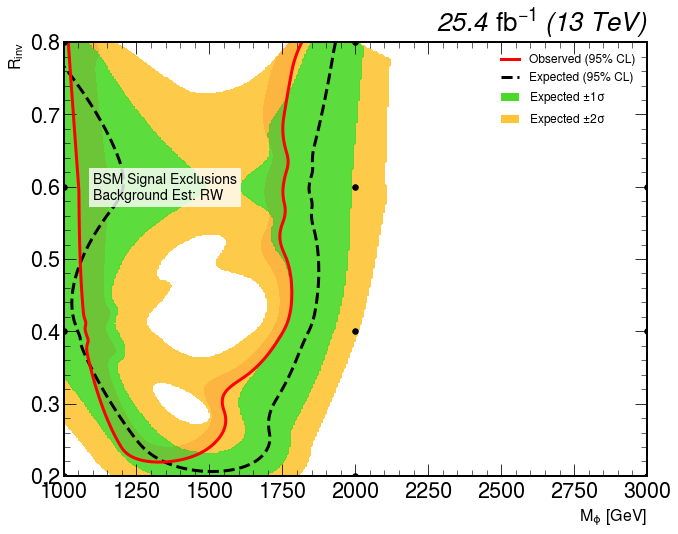

In [ ]:
plot_2d_brazilian(df_limits_rw, DF_META, bkg_type="RW")

--- Running Shape Analysis pyhf Limits for Background: NOM ---
  [1000_2] Exp Limit (mu): 0.2411  |  Obs Limit (mu): 0.0314
  [1000_4] Exp Limit (mu): 0.1201  |  Obs Limit (mu): 0.0144
  [1000_6] Exp Limit (mu): 0.0791  |  Obs Limit (mu): 0.0100
  [1000_8] Exp Limit (mu): 0.0565  |  Obs Limit (mu): 0.0100
  [2000_2] Exp Limit (mu): 0.1933  |  Obs Limit (mu): 0.2753
  [2000_4] Exp Limit (mu): 0.9129  |  Obs Limit (mu): 0.2447
  [2000_6] Exp Limit (mu): 0.6865  |  Obs Limit (mu): 0.1716
  [2000_8] Exp Limit (mu): 0.5904  |  Obs Limit (mu): 0.1547
  [3000_2] Exp Limit (mu): 36.9413  |  Obs Limit (mu): 18.4708
  [3000_4] Exp Limit (mu): 17.9881  |  Obs Limit (mu): 8.3428
  [3000_6] Exp Limit (mu): 12.4859  |  Obs Limit (mu): 5.7206
  [3000_8] Exp Limit (mu): 10.3849  |  Obs Limit (mu): 5.0885


/tmp/ipykernel_655970/3730156354.py:88: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", label="", data=True, lumi=25.4, ax=ax, loc=0)


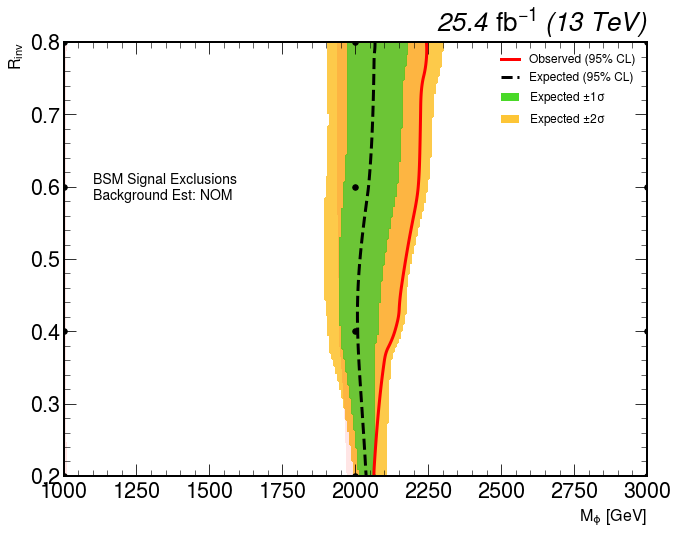

In [ ]:
# Assuming optimal cuts were generated:
df_limits_nom = calculate_pyhf_limits(
    df_sig_dict=df_sig_def, 
    signal_modes=SIGNAL_MODES, 
    df_mc=df_mc_rw, 
    df_data=df_data, 
    bkg_type="NOM", 
    score_cuts=opt_cut_results["NOM_default"], 
    df_meta=DF_META,
    mjj_bins=MJJ_BINS, # <-- Added here
    bkg_syst_frac=0.10, 
    cut_direction="greater" # Or "greater" based on your classifier
)
# Render the 2D Brazilian plot
plot_2d_brazilian(df_limits_nom, DF_META, bkg_type="NOM")

In [ ]:
df_limits_gen.to_csv('cwola_gen.csv', index=False)
df_limits_rw.to_csv('cwola_rw.csv', index=False)
df_limits_nom.to_csv('cwola_nom.csv', index=False)